# A systematic comparison of the factors influencing forest height estimation from single-pass interferometric data, using inverse and machine-learning methods

**Anton Kostiukhin**<sup>1,2</sup>, **Tauri Tampuu**<sup>1</sup>, **Alexander Kmoch**<sup>2</sup>, **Jaan Praks**<sup>3</sup>, **Martin Jüssi**<sup>1</sup>

<sup>1</sup> Kappazeta Ltd., Kastani 42, Tartu 50410, Estonia  
<sup>2</sup> Landscape Geoinformatics Lab, Department of Geography, Institute of Ecology and Earth Sciences, University of Tartu, Vanemuise 46, Tartu 51003, Estonia  
<sup>3</sup> Department of Electronics and Nanoengineering, School of Electrical Engineering, Aalto University, Maarintie 8, Espoo 02150, Finland

---

## Random Forest model

In [1]:
import os
import re
import glob
import shap
import math
import rasterio
import itertools
import numpy as np
import pandas as pd
import seaborn as sns
import geopandas as gpd
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET

from itertools import chain
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

/home/anton/miniconda3/envs/tdx-ts2/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Input path and information

In [ ]:
tdx_parent_path = "/tandem-x/batch_2024/{site}/1.6.2"

training_features_info_dict = {
    "SIGMA0": {
        "role": ["MST", ],      # Wether data layer is derived from master, slave, or interferogram
        "pol": ["VV", "VH"],    # Polarization
        "agg": ["mean"],        # Function to aggregate in zonal statistics
        "human": "Sigma0"       # Human-readable name
    },
    "COH": {
        "role": ["NAN"],
        "pol": ["VV", "VH"],
        "agg": ["mean"],
        "human": "Coherence"
    },
    "HOA2HC": {
        "role": ["NAN"],
        "pol": ["VV", "VH"],
        "agg": ["mean"],
        "human": "InSAR height"
    },
    "HOA": {
        "role": ["NAN"],
        "pol": ["00"],
        "agg": ["mean"],
        "human": "Height of Ambiguity"
    },
    "LAT": {
        "role": ["NAN"],
        "pol": ["00"],
        "agg": ["mean"],
        "human": "Latitude"
    },
    "LON": {
        "role": ["NAN"],
        "pol": ["00"],
        "agg": ["mean"],
        "human": "Longitude"
    },
    "EIA": {
        "role": ["NAN"],
        "pol": ["00"],
        "agg": ["mean"],
        "human": "Ellipsoid Incidence Angle"
    },
    "LIA": {
        "role": ["NAN"],
        "pol": ["00"],
        "agg": ["mean"],
        "human": "Local Incidence Angle"
    },
    "SLOPE": {
        "role": ["NAN"],
        "pol": ["00"],
        "agg": ["mean"],
        "human": "Slope"
    },
    "ASPECT": {
        "role": ["NAN"],
        "pol": ["00"],
        "agg": ["mean"],
        "human": "Aspect"
    },
    "ORIENTEDASPECT": {
        "role": ["NAN"],
        "pol": ["00"],
        "agg": ["mean"],
        "human": "Oriented aspect"
    },
    "ELEVATION": {
        "role": ["NAN"],
        "pol": ["00"],
        "agg": ["mean"],
        "human": "Elevation"
    },
}

validation_feature_key = "MAA_HAG_21K_22K_23K"

In [3]:
tdx_products_list = []

for site in [
    "pikknurme_100", 
    "saaremaa_100"
]:
    products = glob.glob(
        os.path.join(tdx_parent_path.format(site=site), "*"), 
        recursive=True
    )
    tdx_products_list.extend(products)

print("Products found:", len(tdx_products_list))

Products found: 39


In [4]:
tdx_products_to_keep = {
    "HoA_35_LEAVES_ON": [
        # Pikknurme
        "TDM1_SAR__COS_BIST_SM_D_SRA_20240805T045033_20240805T045036", #	D	24.654	-36.022	    102.203	TDX-1
        "TDM1_SAR__COS_BIST_SM_D_SRA_20240805T045035_20240805T045041", #	D	24.67	-35.911	    102.203	TDX-1
        # Saaremaa
        "TDM1_SAR__COS_BIST_SM_D_SRA_20240804T050753_20240804T050758", #	D	22.135	33.351	    97.943	TSX-1
        "TDM1_SAR__COS_BIST_SM_D_SRA_20240804T050757_20240804T050801", #	D	22.149	33.246	    97.943	TSX-1 +
        "TDM1_SAR__COS_BIST_SM_D_SRA_20240815T050753_20240815T050758", #	D	23.429	35.138	    98.906	TSX-1
        "TDM1_SAR__COS_BIST_SM_D_SRA_20240815T050757_20240815T050802", #	D	23.44	35.031	    98.906	TSX-1
    ],
    "HoA_35_LEAVES_OFF": [
        # Pikknurme
        "TDM1_SAR__COS_BIST_SM_D_SRA_20241226T045033_20241226T045036", #	D	24.662	-35.73	    103.007	TDX-1
        "TDM1_SAR__COS_BIST_SM_D_SRA_20241226T045035_20241226T045041", #	D	24.679	-35.633	    103.007	TDX-1
        # Saaremaa
        "TDM1_SAR__COS_BIST_SM_D_SRA_20241225T050753_20241225T050758", #	D	22.181	32.684	    100.091	TSX-1
        "TDM1_SAR__COS_BIST_SM_D_SRA_20241225T050757_20241225T050802", #	D	22.195	32.593	    100.091	TSX-1 +
    ],
    "HoA_50_LEAVES_ON": [
        # Pikknurme
        "TDM1_SAR__COS_BIST_SM_D_SRA_20240811T044159_20240811T044206", #	D	35.863	50.881	    112.64	TSX-1
        "TDM1_SAR__COS_BIST_SM_D_SRA_20240811T044205_20240811T044208", #	D	35.866	50.772	    112.64	TSX-1
    ],
    "HoA_50_LEAVES_OFF": [
        # Pikknurme
        "TDM1_SAR__COS_BIST_SM_D_SRA_20241221T044200_20241221T044207", #	D	35.894	-50.683	    113.082	TDX-1
        "TDM1_SAR__COS_BIST_SM_D_SRA_20241221T044206_20241221T044209", #	D	35.897	-50.591	    113.082	TDX-1
        # Saaremaa
        "TDM1_SAR__COS_BIST_SM_D_SRA_20241220T045921_20241220T045929", #	D	33.837	-47.566	    111.833	TDX-1
        "TDM1_SAR__COS_BIST_SM_D_SRA_20241220T045926_20241220T045929", #	D	33.838	-47.489	    111.833	TDX-1
    ],
    "HoA_60_LEAVES_ON": [
        # Pikknurme
        "TDM1_SAR__COS_BIST_SM_D_SRA_20240806T043325_20240806T043328", #	D	44.944	64.983	    120.07	TSX-1
        "TDM1_SAR__COS_BIST_SM_D_SRA_20240806T043327_20240806T043334", #	D	44.952	64.882	    120.07	TSX-1
        ## Saaremaa
        "TDM1_SAR__COS_BIST_SM_D_SRA_20240816T045046_20240816T045051", #	D	44.133	64.12	    118.4	TSX-1
        "TDM1_SAR__COS_BIST_SM_D_SRA_20240816T045050_20240816T045055", #	D	44.139	64.022	    118.4	TSX-1
    ],
    "HoA_60_LEAVES_OFF": [
        # Pikknurme
        "TDM1_SAR__COS_BIST_SM_D_SRA_20241005T044202_20241005T044209", #	D	35.888	-57.242	    100.157	TDX-1
        "TDM1_SAR__COS_BIST_SM_D_SRA_20241005T044208_20241005T044211", #	D	35.891	-57.146	    100.157	TDX-1
        "TDM1_SAR__COS_BIST_SM_D_SRA_20241227T043325_20241227T043329", #	D	44.982	-63.713	    122.413	TDX-1
        "TDM1_SAR__COS_BIST_SM_D_SRA_20241227T043328_20241227T043334", #	D	44.991	-63.628	    122.413	TDX-1
    ],
    "HoA_250_LEAVES_ON": [
        # No products from summer time
    ],
    "HoA_250_LEAVES_OFF": [
        # Pikknurme
        "TDM1_SAR__COS_BIST_SM_D_SRA_20241009T155519_20241009T155524", #	A	40.655	-238.789	28.298	TDX-1
        "TDM1_SAR__COS_BIST_SM_D_SRA_20241009T155523_20241009T155527", #	A	40.65	-235.898	28.298	TDX-1
        "TDM1_SAR__COS_BIST_SM_D_SRA_20241225T155515_20241225T155521", #	A	40.679	-282.545	23.967	TDX-1
        "TDM1_SAR__COS_BIST_SM_D_SRA_20241225T155520_20241225T155524", #	A	40.674	-277.649	23.967	TDX-1
        # Saaremaa
        "TDM1_SAR__COS_BIST_SM_D_SRA_20241008T161227_20241008T161232", #	A	40.68	-256.363	26.453	TDX-1
        "TDM1_SAR__COS_BIST_SM_D_SRA_20241008T161231_20241008T161236", #	A	40.674	-252.958	26.453	TDX-1
    ],
    "HoA_370_LEAVES_ON": [
        # Pikknurme
        "TDM1_SAR__COS_BIST_SM_D_SRA_20240804T155515_20240804T155521", #	A	40.672	-372.034	18.24	TDX-1
        "TDM1_SAR__COS_BIST_SM_D_SRA_20240804T155520_20240804T155524", #	A	40.667	-363.571	18.24	TDX-1
        # Saaremaa
        "TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161223_20240803T161228", #	A	40.675	-401.384	16.984	TDX-1
        "TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161227_20240803T161232", #	A	40.668	-391.554	16.984	TDX-1
    ],
    "HoA_370_LEAVES_OFF": [
        # No products from winter time
    ]
}

tdx_products_to_discard = [
    # Pikknurme
    "TDM1_SAR__COS_BIST_SM_D_SRA_20241004T154644_20241004T154647", #	A	30.54	-488.453	10.235	TDX-1
    "TDM1_SAR__COS_BIST_SM_D_SRA_20241004T154646_20241004T154653", #	A	30.527	-474.071	10.235	TDX-1
    # Saarema
    "TDM1_SAR__COS_BIST_SM_D_SRA_20241230T160350_20241230T160353", #	A	30.571	-1187.529	4.836	TDX-1
    "TDM1_SAR__COS_BIST_SM_D_SRA_20241230T160350_20241230T160358", #	A	30.557	-1106.225	4.836	TDX-1
    "TDM1_SAR__COS_BIST_SM_D_SRA_20241230T160355_20241230T160358", #	A	30.557	-1024.106	4.836	TDX-1
]

tdx_products_list = [x for x in tdx_products_list if any(k in x for k in list(chain.from_iterable(tdx_products_to_keep.values())))]

print("Products found:", len(tdx_products_list))

Products found: 34


Miscellaneous functions

In [5]:
def get_random_number():
    return 42

def get_pretty_names(names_in):
    pretty_map = {}

    for name in names_in:
        split = name.split("_")
        if len(split) != 4:
            _dict = {
                "is_coniferous": "Forest type",
                "is_winter": "Seasonality",
                "prec_mm": "Precipitation",
            }
            pretty = _dict.get(name)
        else:
            key = split[1].upper()
            desc = training_features_info_dict.get(key)

            pretty = [
                desc["human"],
                "({})".format(split[2].upper()) if split[2] != "00" else None
            ]
            pretty = [x for x in pretty if x is not None]

            pretty = " ".join(pretty)
        
        pretty_map[name] = pretty

    return pretty_map

Data readers

In [6]:
def read_product_metadata(df, tdx_path):
    """
    Read product metadata from dim files and write into corresponding dataframe.
    """
    dim_file = os.path.join(tdx_path, "*.dim")
    dim_file = glob.glob(dim_file, recursive=True)[0]

    tdm_tree = ET.parse(dim_file).getroot()
    
    orbit_direction = tdm_tree.find(".//MDElem[@name='CoSSC_Metadata']//MDATTR[@name='orbitDirection']").text
    incidence_angle = round(float(tdm_tree.find(".//MDElem[@name='CoSSC_Metadata']//MDElem[@name='sceneCenterCoord']//MDATTR[@name='incidenceAngle']").text), 3)
    hoa = round(float(tdm_tree.find(".//MDATTR[@name='heightOfAmbiguity']").text), 3)
    effective_baseline = round(float(tdm_tree.find(".//MDATTR[@name='effectiveBaseline']").text), 3)
    _id_master_sat = tdm_tree.find(".//MDATTR[@name='inSARmasterID']").text
    master_sat = tdm_tree.find(f".//MDATTR[@name='satelliteID{_id_master_sat.lower()}']").text

    df["md_name"] = os.path.basename(tdx_path)
    df["md_incidence_angle"] = incidence_angle
    df["md_hoa"] = abs(hoa)
    df["md_orbit"] = 0 if orbit_direction == "D" else 1
    df["md_master_satellite"] = 1 if master_sat == "TDX-1" else 0
    df["md_effective_baseline"] = effective_baseline

    # Regex to parse tdm name
    rx = r"TDM1_SAR__COS_BIST_SM_D_SRA_(?P<date>\d{8})T\d{6}_\d{8}T\d{6}"
    rx = re.compile(rx)

    _match = rx.search(tdx_path)
    if _match is None:
        raise ValueError()
    date = _match.group("date")

    df["md_date"] = date

    if "pikknurme_100" in dim_file:
        df["md_site"] = "Pikknurme"
    if "saaremaa_100" in dim_file:
        df["md_site"] = "Saaremaa"

    return df

In [7]:
def read_compartment_ids(df, tdx_path):
    """
    Read raster containing IDs of forest comparmtments.
    """
    raster_file = glob.glob(
        os.path.join(
            tdx_path, "**", "IV", "MTS_GEO_ERALDISID.tif"
        ),
        recursive=True
    )
    raster_file = raster_file.pop()

    with rasterio.open(raster_file) as src:
        arr = src.read(1)
        arr = arr.astype(np.float32)
        arr = np.where(arr == -32768.0, np.nan, arr)
        arr = arr.ravel()

        df["eraldis_id"] = arr

    return df

In [8]:
def read_chm(df, tdx_path):
    """
    Read raster containing validation forest height.
    """
    raster_file = glob.glob(
        os.path.join(
            tdx_path, "**", "IV", f"{validation_feature_key}.tif"
        ),
        recursive=True
    )
    raster_file = raster_file.pop()

    with rasterio.open(raster_file) as src:
        arr = src.read(1)
        arr = arr.astype(np.float32)
        arr = np.where(arr == -32768.0, np.nan, arr)
        arr = arr.ravel()

        df["chm"] = arr

    return df

In [9]:
def read_training_features(df, tdx_path):
    """
    Read SAR obervables used as training features in the modelling.
    """
    # Regex to parse names of TDM feature files
    rx = r"(?P<sat>TDX|TSX|TDM)_(?P<role>MST|SLV|NAN)_(\d{8}T\d{6}_\d{8}T\d{6})_(?P<key>[A-Za-z0-9]+)_(?P<pol>\w+).tif"
    rx = re.compile(rx)

    # Based on existing tif files pick those which are needed
    l3_feature_files = os.path.join(tdx_path, "**", "III", "*.tif")
    l3_feature_files = glob.glob(l3_feature_files, recursive=True)

    for l3_file in l3_feature_files:
        _match = rx.search(l3_file)
        if _match is None:
            continue
        role = _match.group("role")
        key = _match.group("key")
        pol = _match.group("pol")

        is_requested = training_features_info_dict.get(key, {})
        is_requested =  role in is_requested.get("role", []) and pol in is_requested.get("pol", [])
        if is_requested:
            with rasterio.open(l3_file) as src:
                arr = src.read(1)
                arr = arr.astype(np.float32)
                arr = np.where(arr == -32768.0, np.nan, arr)
                arr = arr.ravel()

                _column = "{}_{}_{}".format(role, key, pol).lower()
                df[_column] = arr

    return df

In [10]:
samples_all_df = []

for tdx_path in tdx_products_list:
    print(os.path.basename(tdx_path))

    # Read features
    df = pd.DataFrame()
    df = read_compartment_ids(df, tdx_path)
    df = read_product_metadata(df, tdx_path)
    df = read_chm(df, tdx_path)
    df = read_training_features(df, tdx_path)

    # Concat all samples
    df = df[df["eraldis_id"].notna()]
    df = df[df["chm"].notna()]

    samples_all_df.append(df)

samples_all_df = pd.concat(samples_all_df, ignore_index=True)

TDM1_SAR__COS_BIST_SM_D_SRA_20240804T155515_20240804T155521
TDM1_SAR__COS_BIST_SM_D_SRA_20240804T155520_20240804T155524
TDM1_SAR__COS_BIST_SM_D_SRA_20240805T045033_20240805T045036
TDM1_SAR__COS_BIST_SM_D_SRA_20240805T045035_20240805T045041
TDM1_SAR__COS_BIST_SM_D_SRA_20240806T043325_20240806T043328
TDM1_SAR__COS_BIST_SM_D_SRA_20240806T043327_20240806T043334
TDM1_SAR__COS_BIST_SM_D_SRA_20240811T044159_20240811T044206
TDM1_SAR__COS_BIST_SM_D_SRA_20240811T044205_20240811T044208
TDM1_SAR__COS_BIST_SM_D_SRA_20241005T044202_20241005T044209
TDM1_SAR__COS_BIST_SM_D_SRA_20241005T044208_20241005T044211
TDM1_SAR__COS_BIST_SM_D_SRA_20241009T155519_20241009T155524
TDM1_SAR__COS_BIST_SM_D_SRA_20241009T155523_20241009T155527
TDM1_SAR__COS_BIST_SM_D_SRA_20241221T044200_20241221T044207
TDM1_SAR__COS_BIST_SM_D_SRA_20241221T044206_20241221T044209
TDM1_SAR__COS_BIST_SM_D_SRA_20241225T155515_20241225T155521
TDM1_SAR__COS_BIST_SM_D_SRA_20241225T155520_20241225T155524
TDM1_SAR__COS_BIST_SM_D_SRA_20241226T045

In [11]:
# Sort and check contents
samples_all_df = samples_all_df.sort_values(by=["eraldis_id", "md_name"], ascending=[True, True])
samples_all_df.head(10)

,eraldis_id,md_name,md_incidence_angle,md_hoa,md_orbit,md_master_satellite,md_effective_baseline,md_date,md_site,chm,...,nan_hoa_00,nan_hoa2hc_vv,nan_coh_vv,mst_sigma0_vv,nan_hoa2hc_vh,nan_coh_vh,mst_sigma0_vh,nan_slope_00,nan_aspect_00,nan_orientedaspect_00
15994695,100641.0,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161227_20...,40.668,391.554,1,1,16.984,20240803,Saaremaa,16.332607,...,393.983734,16.404902,0.844823,0.046283,27.577700,0.664133,0.038452,0.996280,47.532787,333.374908
15994734,100641.0,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161227_20...,40.668,391.554,1,1,16.984,20240803,Saaremaa,17.720924,...,393.982117,13.906308,0.834880,0.090877,12.272013,0.685572,0.031864,1.276899,54.037655,339.879791
15994735,100641.0,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161227_20...,40.668,391.554,1,1,16.984,20240803,Saaremaa,17.511700,...,393.991913,18.577776,0.841783,0.089370,16.985731,0.763299,0.028028,0.947084,55.319439,341.161560
15994775,100641.0,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161227_20...,40.668,391.554,1,1,16.984,20240803,Saaremaa,19.391788,...,393.980469,14.887515,0.851518,0.107674,17.330866,0.702246,0.007264,1.216404,54.083836,339.925964
15994776,100641.0,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161227_20...,40.668,391.554,1,1,16.984,20240803,Saaremaa,18.495867,...,393.990326,15.094254,0.852751,0.046685,17.194750,0.799055,0.033441,1.260374,55.648655,341.490784
15994777,100641.0,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161227_20...,40.668,391.554,1,1,16.984,20240803,Saaremaa,18.109465,...,394.000122,13.602020,0.854786,0.057455,15.500176,0.827167,0.014755,1.062294,58.427864,344.269989
15994818,100641.0,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161227_20...,40.668,391.554,1,1,16.984,20240803,Saaremaa,18.211636,...,393.978882,13.799279,0.861689,0.077345,12.767344,0.613956,0.009913,0.882502,48.549515,334.391663
15994819,100641.0,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161227_20...,40.668,391.554,1,1,16.984,20240803,Saaremaa,17.789562,...,393.988739,17.295654,0.849093,0.072992,17.276703,0.759067,0.028665,1.412794,57.493870,343.335999
15994820,100641.0,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161227_20...,40.668,391.554,1,1,16.984,20240803,Saaremaa,17.122274,...,393.998596,14.763548,0.875715,0.057814,16.183722,0.809592,0.017533,1.195899,54.441692,340.283813
15994821,100641.0,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161227_20...,40.668,391.554,1,1,16.984,20240803,Saaremaa,18.720772,...,394.008331,12.710437,0.840488,0.126816,8.636123,0.731199,0.031877,1.047628,50.157318,335.999451


Remove compartments from overlapping areas between same-day products

In [12]:
# Find the earliest product per parcel_id and date
earliest_md = (
    samples_all_df.groupby(["eraldis_id", "md_date"])["md_name"]
    .min()
    .reset_index()
)
earliest_md.head(10)

,eraldis_id,md_date,md_name
0,100641.0,20240803,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161227_20...
1,100641.0,20240815,TDM1_SAR__COS_BIST_SM_D_SRA_20240815T050753_20...
2,100641.0,20240816,TDM1_SAR__COS_BIST_SM_D_SRA_20240816T045046_20...
3,100641.0,20241008,TDM1_SAR__COS_BIST_SM_D_SRA_20241008T161231_20...
4,748875.0,20240811,TDM1_SAR__COS_BIST_SM_D_SRA_20240811T044159_20...
5,748875.0,20241005,TDM1_SAR__COS_BIST_SM_D_SRA_20241005T044202_20...
6,748875.0,20241009,TDM1_SAR__COS_BIST_SM_D_SRA_20241009T155523_20...
7,748875.0,20241221,TDM1_SAR__COS_BIST_SM_D_SRA_20241221T044200_20...
8,748875.0,20241225,TDM1_SAR__COS_BIST_SM_D_SRA_20241225T155520_20...
9,748875.0,20241226,TDM1_SAR__COS_BIST_SM_D_SRA_20241226T045033_20...


In [13]:
# Keep only rows matching the earliest product
samples_all_df = samples_all_df.merge(earliest_md, on=["eraldis_id", "md_date", "md_name"])
samples_all_df.head(10)

,eraldis_id,md_name,md_incidence_angle,md_hoa,md_orbit,md_master_satellite,md_effective_baseline,md_date,md_site,chm,...,nan_hoa_00,nan_hoa2hc_vv,nan_coh_vv,mst_sigma0_vv,nan_hoa2hc_vh,nan_coh_vh,mst_sigma0_vh,nan_slope_00,nan_aspect_00,nan_orientedaspect_00
0,100641.0,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161227_20...,40.668,391.554,1,1,16.984,20240803,Saaremaa,16.332607,...,393.983734,16.404902,0.844823,0.046283,27.577700,0.664133,0.038452,0.996280,47.532787,333.374908
1,100641.0,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161227_20...,40.668,391.554,1,1,16.984,20240803,Saaremaa,17.720924,...,393.982117,13.906308,0.834880,0.090877,12.272013,0.685572,0.031864,1.276899,54.037655,339.879791
2,100641.0,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161227_20...,40.668,391.554,1,1,16.984,20240803,Saaremaa,17.511700,...,393.991913,18.577776,0.841783,0.089370,16.985731,0.763299,0.028028,0.947084,55.319439,341.161560
3,100641.0,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161227_20...,40.668,391.554,1,1,16.984,20240803,Saaremaa,19.391788,...,393.980469,14.887515,0.851518,0.107674,17.330866,0.702246,0.007264,1.216404,54.083836,339.925964
4,100641.0,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161227_20...,40.668,391.554,1,1,16.984,20240803,Saaremaa,18.495867,...,393.990326,15.094254,0.852751,0.046685,17.194750,0.799055,0.033441,1.260374,55.648655,341.490784
5,100641.0,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161227_20...,40.668,391.554,1,1,16.984,20240803,Saaremaa,18.109465,...,394.000122,13.602020,0.854786,0.057455,15.500176,0.827167,0.014755,1.062294,58.427864,344.269989
6,100641.0,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161227_20...,40.668,391.554,1,1,16.984,20240803,Saaremaa,18.211636,...,393.978882,13.799279,0.861689,0.077345,12.767344,0.613956,0.009913,0.882502,48.549515,334.391663
7,100641.0,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161227_20...,40.668,391.554,1,1,16.984,20240803,Saaremaa,17.789562,...,393.988739,17.295654,0.849093,0.072992,17.276703,0.759067,0.028665,1.412794,57.493870,343.335999
8,100641.0,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161227_20...,40.668,391.554,1,1,16.984,20240803,Saaremaa,17.122274,...,393.998596,14.763548,0.875715,0.057814,16.183722,0.809592,0.017533,1.195899,54.441692,340.283813
9,100641.0,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161227_20...,40.668,391.554,1,1,16.984,20240803,Saaremaa,18.720772,...,394.008331,12.710437,0.840488,0.126816,8.636123,0.731199,0.031877,1.047628,50.157318,335.999451


Remove extreme and unreasonable values from height rasters

In [14]:
columns_by = ["hoa2hc"]

for c in samples_all_df.columns:
    if any(key in c for key in columns_by):
        samples_all_df = samples_all_df[((samples_all_df[c] >= 0.0)) & (samples_all_df[c] <= 50.0)]

samples_all_df

,eraldis_id,md_name,md_incidence_angle,md_hoa,md_orbit,md_master_satellite,md_effective_baseline,md_date,md_site,chm,...,nan_hoa_00,nan_hoa2hc_vv,nan_coh_vv,mst_sigma0_vv,nan_hoa2hc_vh,nan_coh_vh,mst_sigma0_vh,nan_slope_00,nan_aspect_00,nan_orientedaspect_00
0,100641.0,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161227_20...,40.668,391.554,1,1,16.984,20240803,Saaremaa,16.332607,...,393.983734,16.404902,0.844823,0.046283,27.577700,0.664133,0.038452,0.996280,47.532787,333.374908
1,100641.0,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161227_20...,40.668,391.554,1,1,16.984,20240803,Saaremaa,17.720924,...,393.982117,13.906308,0.834880,0.090877,12.272013,0.685572,0.031864,1.276899,54.037655,339.879791
2,100641.0,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161227_20...,40.668,391.554,1,1,16.984,20240803,Saaremaa,17.511700,...,393.991913,18.577776,0.841783,0.089370,16.985731,0.763299,0.028028,0.947084,55.319439,341.161560
3,100641.0,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161227_20...,40.668,391.554,1,1,16.984,20240803,Saaremaa,19.391788,...,393.980469,14.887515,0.851518,0.107674,17.330866,0.702246,0.007264,1.216404,54.083836,339.925964
4,100641.0,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161227_20...,40.668,391.554,1,1,16.984,20240803,Saaremaa,18.495867,...,393.990326,15.094254,0.852751,0.046685,17.194750,0.799055,0.033441,1.260374,55.648655,341.490784
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17798972,11848819.0,TDM1_SAR__COS_BIST_SM_D_SRA_20241225T050753_20...,22.181,32.684,0,0,100.091,20241225,Saaremaa,17.870321,...,32.241234,0.891420,0.338571,0.084461,3.636387,0.390664,0.031894,1.460692,288.846252,2.793396
17798973,11848819.0,TDM1_SAR__COS_BIST_SM_D_SRA_20241225T050753_20...,22.181,32.684,0,0,100.091,20241225,Saaremaa,19.996056,...,32.239536,1.274681,0.208726,0.062243,4.281916,0.291848,0.060414,1.161240,281.112000,355.059143
17798974,11848819.0,TDM1_SAR__COS_BIST_SM_D_SRA_20241225T050753_20...,22.181,32.684,0,0,100.091,20241225,Saaremaa,20.715813,...,32.237907,0.961157,0.156935,0.108390,3.323581,0.166935,0.033226,0.548352,257.764954,331.712097
17798975,11848819.0,TDM1_SAR__COS_BIST_SM_D_SRA_20241225T050753_20...,22.181,32.684,0,0,100.091,20241225,Saaremaa,18.817926,...,32.240768,0.878328,0.449186,0.089944,2.099392,0.419438,0.019567,1.437760,304.894135,18.841278


Aggregate per product and comparment and calculate compartment based statistics

In [15]:
agg_dict = {
    "md_site": ("md_site", "first"),
    "md_orbit": ("md_orbit", "first"),
    "md_incidence_angle": ("md_incidence_angle", "first"),
    "md_hoa": ("md_hoa", "first"),
    "md_master_satellite": ("md_master_satellite", "first"),
    "md_effective_baseline": ("md_effective_baseline", "first"),
    "md_date": ("md_date", "first"),

    "chm_mean": ("chm", "mean"),
}

for base_name, params in training_features_info_dict.items():
    # Generate all combinations of role, pol, and agg
    for role, pol, agg in itertools.product(params["role"], params["pol"], params["agg"]):
        # Create column name
        inp_col_name = f"{role}_{base_name}_{pol}".lower()
        agg_col_name = f"{role}_{base_name}_{pol}_{agg}".lower()

        # Add to aggregation dict
        agg_dict[agg_col_name] = (inp_col_name, agg)

print("Generated aggregation dictionary:")
for key, value in agg_dict.items():
    print(f"{key}={value}")

Generated aggregation dictionary:
md_site=('md_site', 'first')
md_orbit=('md_orbit', 'first')
md_incidence_angle=('md_incidence_angle', 'first')
md_hoa=('md_hoa', 'first')
md_master_satellite=('md_master_satellite', 'first')
md_effective_baseline=('md_effective_baseline', 'first')
md_date=('md_date', 'first')
chm_mean=('chm', 'mean')
mst_sigma0_vv_mean=('mst_sigma0_vv', 'mean')
mst_sigma0_vh_mean=('mst_sigma0_vh', 'mean')
nan_coh_vv_mean=('nan_coh_vv', 'mean')
nan_coh_vh_mean=('nan_coh_vh', 'mean')
nan_hoa2hc_vv_mean=('nan_hoa2hc_vv', 'mean')
nan_hoa2hc_vh_mean=('nan_hoa2hc_vh', 'mean')
nan_hoa_00_mean=('nan_hoa_00', 'mean')
nan_lat_00_mean=('nan_lat_00', 'mean')
nan_lon_00_mean=('nan_lon_00', 'mean')
nan_eia_00_mean=('nan_eia_00', 'mean')
nan_lia_00_mean=('nan_lia_00', 'mean')
nan_slope_00_mean=('nan_slope_00', 'mean')
nan_aspect_00_mean=('nan_aspect_00', 'mean')
nan_orientedaspect_00_mean=('nan_orientedaspect_00', 'mean')
nan_elevation_00_mean=('nan_elevation_00', 'mean')


In [16]:
samples_agg_df = samples_all_df.groupby(["md_name", "eraldis_id"]).agg(**agg_dict).reset_index()
samples_agg_df.head(10)

,md_name,eraldis_id,md_site,md_orbit,md_incidence_angle,md_hoa,md_master_satellite,md_effective_baseline,md_date,chm_mean,...,nan_hoa2hc_vh_mean,nan_hoa_00_mean,nan_lat_00_mean,nan_lon_00_mean,nan_eia_00_mean,nan_lia_00_mean,nan_slope_00_mean,nan_aspect_00_mean,nan_orientedaspect_00_mean,nan_elevation_00_mean
0,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161223_20...,836089.0,Saaremaa,1,40.675,401.384,1,16.984,20240803,21.364841,...,14.831244,395.292297,58.250961,22.141972,40.719383,40.598938,2.843423,227.462509,175.494537,50.702137
1,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161223_20...,836113.0,Saaremaa,1,40.675,401.384,1,16.984,20240803,22.550751,...,14.768172,395.124878,58.250698,22.139111,40.706768,40.853992,1.711617,196.023285,168.864197,49.973747
2,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161223_20...,836123.0,Saaremaa,1,40.675,401.384,1,16.984,20240803,21.746855,...,14.445884,395.266968,58.252422,22.140991,40.717407,40.941429,1.062674,201.796860,143.704330,49.964466
3,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161223_20...,1103561.0,Saaremaa,1,40.675,401.384,1,16.984,20240803,11.547481,...,7.728849,402.770355,58.254574,22.272240,41.277847,41.380550,0.475115,153.930786,110.551910,21.249025
4,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161223_20...,1103569.0,Saaremaa,1,40.675,401.384,1,16.984,20240803,11.531087,...,8.112618,402.228882,58.248970,22.264574,41.237427,41.270168,0.053075,127.304199,155.925323,20.845320
5,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161223_20...,1103575.0,Saaremaa,1,40.675,401.384,1,16.984,20240803,12.968261,...,6.339990,402.616272,58.253807,22.269773,41.266361,41.131481,0.283200,195.261566,121.025536,20.923264
6,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161223_20...,1237159.0,Saaremaa,1,40.675,401.384,1,16.984,20240803,17.340286,...,9.234203,395.581055,58.268978,22.140745,40.740665,42.287189,1.657768,100.092499,31.889999,55.804581
7,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161223_20...,1237187.0,Saaremaa,1,40.675,401.384,1,16.984,20240803,13.338782,...,5.202997,395.423431,58.269867,22.137705,40.729050,41.206566,0.533571,96.698456,73.180656,58.408554
8,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161223_20...,1237201.0,Saaremaa,1,40.675,401.384,1,16.984,20240803,16.370195,...,7.399815,395.428101,58.267902,22.138475,40.729301,41.335693,0.638375,84.180489,130.997101,58.363464
9,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161223_20...,1237209.0,Saaremaa,1,40.675,401.384,1,16.984,20240803,15.523559,...,7.795362,395.644867,58.267303,22.142424,40.745255,41.019077,0.578185,142.653061,168.199646,54.010784


Encode group info

In [17]:
_name_to_group = {
    name: int(group.split("_")[1]) for group, names in tdx_products_to_keep.items() for name in names
}

samples_agg_df["md_group"] = samples_agg_df["md_name"].map(_name_to_group)

Encode seasonality

In [18]:
_date = pd.to_datetime(samples_agg_df["md_date"], format="%Y%m%d")

samples_agg_df["is_winter"] = (10 <= _date.dt.month).astype(int)

Encode height classes

In [19]:
_bins = np.arange(0, 40.0, 3)
_labels = [f"{int(b*10):04d}" for b in _bins[1:]]

samples_agg_df["height_class"] = pd.cut(samples_agg_df["chm_mean"], bins=_bins, labels=_labels)

Join with forest registry shapefile to bring info about tree species

In [20]:
mts_gdf = gpd.read_file("../metsaregister_bspm75.gpkg")

In [21]:
mts_gdf["l2_height_weighted"] = mts_gdf["l2_height_weighted"].fillna(0.0)

In [22]:
samples_agg_df = samples_agg_df.merge(
    mts_gdf,
    how="left",
    left_on="eraldis_id",
    right_on="eraldis_id"
)
samples_agg_df.head(10)

,md_name,eraldis_id,md_site,md_orbit,md_incidence_angle,md_hoa,md_master_satellite,md_effective_baseline,md_date,chm_mean,...,ownership_code,l1_dominant,l1_height_weighted,l1_tree_count,l2_dominant,l2_height_weighted,l1_l2_mix,prod_overlap_count,compactness,geometry
0,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161223_20...,836089.0,Saaremaa,1,40.675,401.384,1,16.984,20240803,21.364841,...,R,Pine,18.0,455.0,NaN,0.0,Pine,7,0.680328,"MULTIPOLYGON (((390813.465 6458148.766, 390811..."
1,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161223_20...,836113.0,Saaremaa,1,40.675,401.384,1,16.984,20240803,22.550751,...,R,Other Coniferous,23.4,518.0,NaN,0.0,Other Coniferous,7,0.597390,"MULTIPOLYGON (((390771.042 6458296.755, 390780..."
2,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161223_20...,836123.0,Saaremaa,1,40.675,401.384,1,16.984,20240803,21.746855,...,R,Pine,21.0,452.0,NaN,0.0,Pine,7,0.639148,"MULTIPOLYGON (((390782.861 6458411.712, 390844..."
3,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161223_20...,1103561.0,Saaremaa,1,40.675,401.384,1,16.984,20240803,11.547481,...,R,Pine,8.3,1457.0,NaN,0.0,Pine,5,0.667451,"MULTIPOLYGON (((398635.348 6458480.653, 398668..."
4,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161223_20...,1103569.0,Saaremaa,1,40.675,401.384,1,16.984,20240803,11.531087,...,R,Other Deciduous,14.0,1123.0,NaN,0.0,Other Deciduous,6,0.713149,"MULTIPOLYGON (((398132.258 6457810.292, 398149..."
5,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161223_20...,1103575.0,Saaremaa,1,40.675,401.384,1,16.984,20240803,12.968261,...,R,Birch,8.0,1441.0,NaN,0.0,Birch,6,0.412017,"MULTIPOLYGON (((398440.061 6458321.608, 398455..."
6,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161223_20...,1237159.0,Saaremaa,1,40.675,401.384,1,16.984,20240803,17.340286,...,R,Other Deciduous,19.0,306.0,NaN,0.0,Other Deciduous,7,0.365106,"MULTIPOLYGON (((390868.038 6460465.918, 390888..."
7,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161223_20...,1237187.0,Saaremaa,1,40.675,401.384,1,16.984,20240803,13.338782,...,R,"Mixed, Majorly Deciduous",17.2,523.0,NaN,0.0,"Mixed, Majorly Deciduous",7,0.676944,"MULTIPOLYGON (((390587.662 6460369.72, 390623...."
8,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161223_20...,1237201.0,Saaremaa,1,40.675,401.384,1,16.984,20240803,16.370195,...,R,"Mixed, Majorly Deciduous",18.7,514.0,NaN,0.0,"Mixed, Majorly Deciduous",7,0.566860,"MULTIPOLYGON (((390663.891 6460128.28, 390709...."
9,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161223_20...,1237209.0,Saaremaa,1,40.675,401.384,1,16.984,20240803,15.523559,...,R,"Mixed, Majorly Deciduous",18.0,515.0,NaN,0.0,"Mixed, Majorly Deciduous",7,0.496920,"MULTIPOLYGON (((390940.153 6459911.083, 390915..."


Encode forest types

In [23]:
tree_types = [
    "Birch",
    "Pine",
    "Spruce",
    "Mixed"
]

samples_agg_df = samples_agg_df[samples_agg_df["l1_l2_mix"].isin(tree_types)]

In [24]:
is_coniferous_encoding = {
    "Birch": 0,
    "Pine": 1,
    "Spruce": 1,
    "Mixed": 0,
}

samples_agg_df["is_coniferous"] = samples_agg_df["l1_l2_mix"].map(is_coniferous_encoding)

Encode precipitation

In [ ]:
weather = [
    # Jõgeva station
    ("20240804", "Pikknurme", 9.7),
    ("20240805", "Pikknurme", 7.1),
    ("20240806", "Pikknurme", 0.0),
    ("20240811", "Pikknurme", 6.6),
    ("20241004", "Pikknurme", 2.1),
    ("20241005", "Pikknurme", 0.0),
    ("20241009", "Pikknurme", 12.4),
    ("20241221", "Pikknurme", 2.1),
    ("20241225", "Pikknurme", 0.3),
    ("20241226", "Pikknurme", 0.9),

    # Sõrve station
    ("20240803", "Saaremaa", 0.0),
    ("20240804", "Saaremaa", 0.0),
    ("20240815", "Saaremaa", 0.0),
    ("20240816", "Saaremaa", 0.0),
    ("20241008", "Saaremaa", 0.0),
    ("20241220", "Saaremaa", 2.8),
    ("20241225", "Saaremaa", 0.7),
    ("20241230", "Saaremaa", 4.8),
]

weather_df = pd.DataFrame(weather, columns=[
    "date",
    "site",
    "prec_mm",
])

samples_agg_df = samples_agg_df.merge(weather_df, left_on=["md_date", "md_site"], right_on=["date", "site"], how="left")
samples_agg_df.head(10)

,md_name,eraldis_id,md_site,md_orbit,md_incidence_angle,md_hoa,md_master_satellite,md_effective_baseline,md_date,chm_mean,...,l2_dominant,l2_height_weighted,l1_l2_mix,prod_overlap_count,compactness,geometry,is_coniferous,date,site,prec_mm
0,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161223_20...,836089.0,Saaremaa,1,40.675,401.384,1,16.984,20240803,21.364841,...,NaN,0.0,Pine,7,0.680328,"MULTIPOLYGON (((390813.465 6458148.766, 390811...",1,20240803,Saaremaa,0.0
1,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161223_20...,836123.0,Saaremaa,1,40.675,401.384,1,16.984,20240803,21.746855,...,NaN,0.0,Pine,7,0.639148,"MULTIPOLYGON (((390782.861 6458411.712, 390844...",1,20240803,Saaremaa,0.0
2,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161223_20...,1103561.0,Saaremaa,1,40.675,401.384,1,16.984,20240803,11.547481,...,NaN,0.0,Pine,5,0.667451,"MULTIPOLYGON (((398635.348 6458480.653, 398668...",1,20240803,Saaremaa,0.0
3,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161223_20...,1103575.0,Saaremaa,1,40.675,401.384,1,16.984,20240803,12.968261,...,NaN,0.0,Birch,6,0.412017,"MULTIPOLYGON (((398440.061 6458321.608, 398455...",0,20240803,Saaremaa,0.0
4,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161223_20...,1237309.0,Saaremaa,1,40.675,401.384,1,16.984,20240803,18.046654,...,NaN,0.0,Birch,7,0.380143,"MULTIPOLYGON (((390714.721 6459638.246, 390728...",0,20240803,Saaremaa,0.0
5,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161223_20...,1237375.0,Saaremaa,1,40.675,401.384,1,16.984,20240803,16.646362,...,Spruce,12.0,Mixed,7,0.467004,"MULTIPOLYGON (((390795.25 6459725.407, 390778....",0,20240803,Saaremaa,0.0
6,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161223_20...,1840529.0,Saaremaa,1,40.675,401.384,1,16.984,20240803,15.126719,...,NaN,0.0,Pine,7,0.487073,"MULTIPOLYGON (((391244.479 6461667.968, 391268...",1,20240803,Saaremaa,0.0
7,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161223_20...,1840539.0,Saaremaa,1,40.675,401.384,1,16.984,20240803,20.510782,...,NaN,0.0,Pine,6,0.749352,"MULTIPOLYGON (((394186.461 6457656.161, 394191...",1,20240803,Saaremaa,0.0
8,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161223_20...,1840629.0,Saaremaa,1,40.675,401.384,1,16.984,20240803,20.022051,...,Spruce,8.0,Mixed,6,0.385140,"MULTIPOLYGON (((393201.662 6456557.8, 393247.0...",0,20240803,Saaremaa,0.0
9,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161223_20...,1840637.0,Saaremaa,1,40.675,401.384,1,16.984,20240803,11.067296,...,NaN,0.0,Pine,6,0.593575,"MULTIPOLYGON (((394217.669 6456643.564, 394201...",1,20240803,Saaremaa,0.0


Plot correlation heatmap

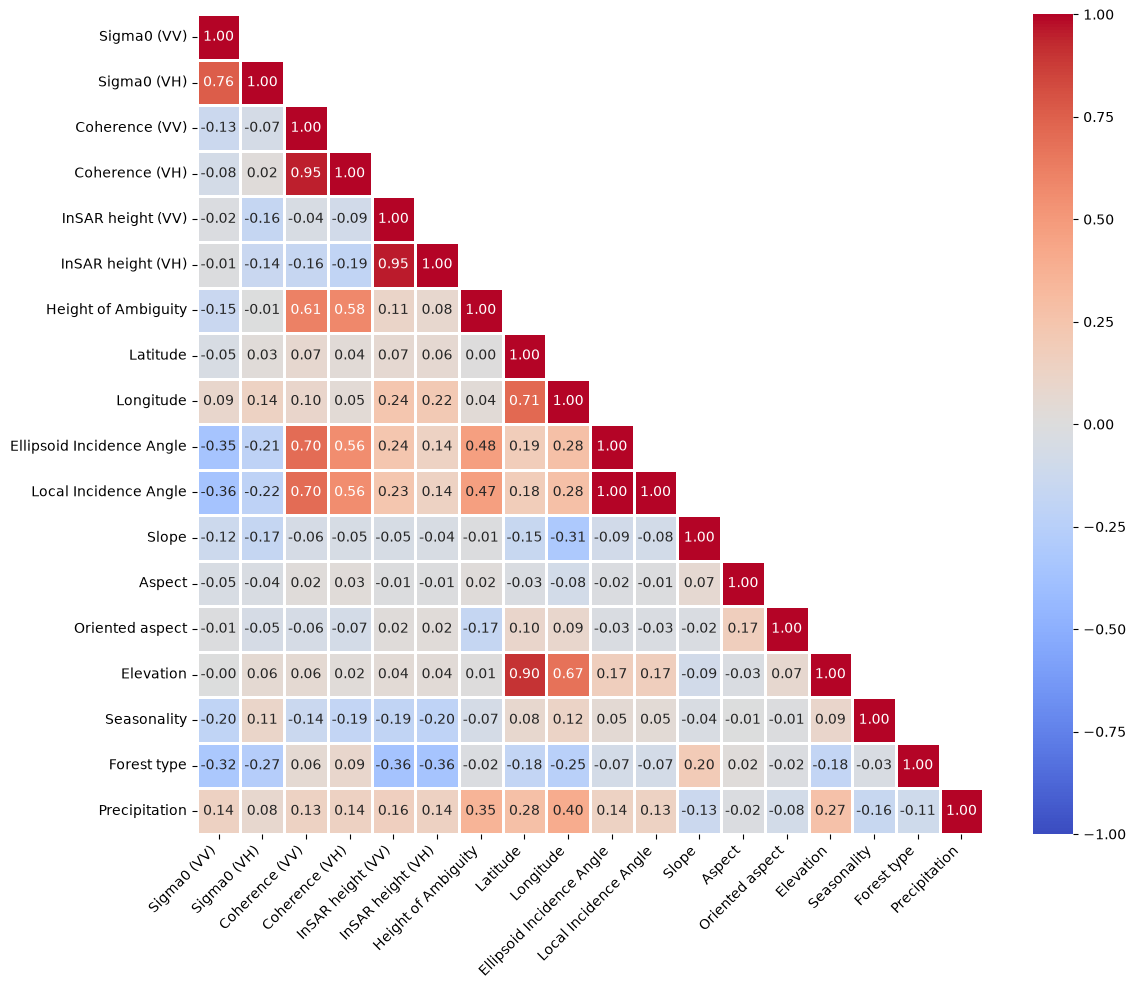

In [26]:
heatmap_features = [
    "mst_sigma0_vv_mean",
    "mst_sigma0_vh_mean",
    "nan_coh_vv_mean",
    "nan_coh_vh_mean",
    "nan_hoa2hc_vv_mean",
    "nan_hoa2hc_vh_mean",
    "nan_hoa_00_mean",
    "nan_lat_00_mean",
    "nan_lon_00_mean",
    "nan_eia_00_mean",
    "nan_lia_00_mean",
    "nan_slope_00_mean",
    "nan_aspect_00_mean",
    "nan_orientedaspect_00_mean",
    "nan_elevation_00_mean",
    "is_winter",
    "is_coniferous",
    "prec_mm"
]

heatmap_matrix = samples_agg_df[heatmap_features].corr()
_pretty_names = get_pretty_names(heatmap_matrix.columns)
heatmap_matrix = heatmap_matrix.rename(index=_pretty_names, columns=_pretty_names)

heatmap_mask = np.triu(np.ones_like(heatmap_matrix, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(12, 10))

sns.heatmap(
    heatmap_matrix,
    mask=heatmap_mask,
    annot=True,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    fmt=".2f",
    linewidths=1,
    annot_kws={"size": 10},
    ax=ax
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=10) 

plt.tight_layout()
plt.show()

Create train and test datasets

In [27]:
# Stratum is needed to perform balancing in the train dataset

def create_stratum(row):
    stratum = (
        str(row["is_coniferous"]) + '_' +
        str(row["is_winter"]) + '_' +
        str(row["md_group"]) + '_' +
        str(row["height_class"])
    )

    return stratum

samples_agg_df["stratum"] = samples_agg_df.apply(create_stratum, axis=1)

In [28]:
# First randomly pick test dataset
test_df = samples_agg_df.sample(n=750, random_state=get_random_number())

# Second, pick train dataset balancing over created stratum
train_df = samples_agg_df.sample(n=0, random_state=get_random_number())

for stratum, group in samples_agg_df.groupby("stratum"):
    train_size_per_stratum = 20

    # In train consider only compartments which are not present in the test
    train_pool = group[~group["eraldis_id"].isin(test_df["eraldis_id"])]

    if len(train_pool) == 0:
        continue

    train_sample = train_pool.sample(n=min(train_size_per_stratum, len(train_pool)), random_state=get_random_number())

    train_df = pd.concat([train_df, train_sample], ignore_index=True)

leaked = set(train_df["eraldis_id"]) & set(test_df["eraldis_id"])

print(f"Leaked compartments : {len(leaked)}")
print(f"Train rows          : {len(train_df)}")
print(f"Test rows           : {len(test_df)}")

Leaked compartments : 0
Train rows          : 3029
Test rows           : 750


Plot histogram of features

In [29]:
if True:
    from matplotlib import font_manager
    
    font_path = "../Inter-SemiBold.otf"
    
    font_manager.fontManager.addfont(font_path)
    font_name = font_manager.FontProperties(fname=font_path).get_name()
    plt.rcParams["font.family"] = font_name

findfont: Failed to find font weight normal, now using 600.


findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.


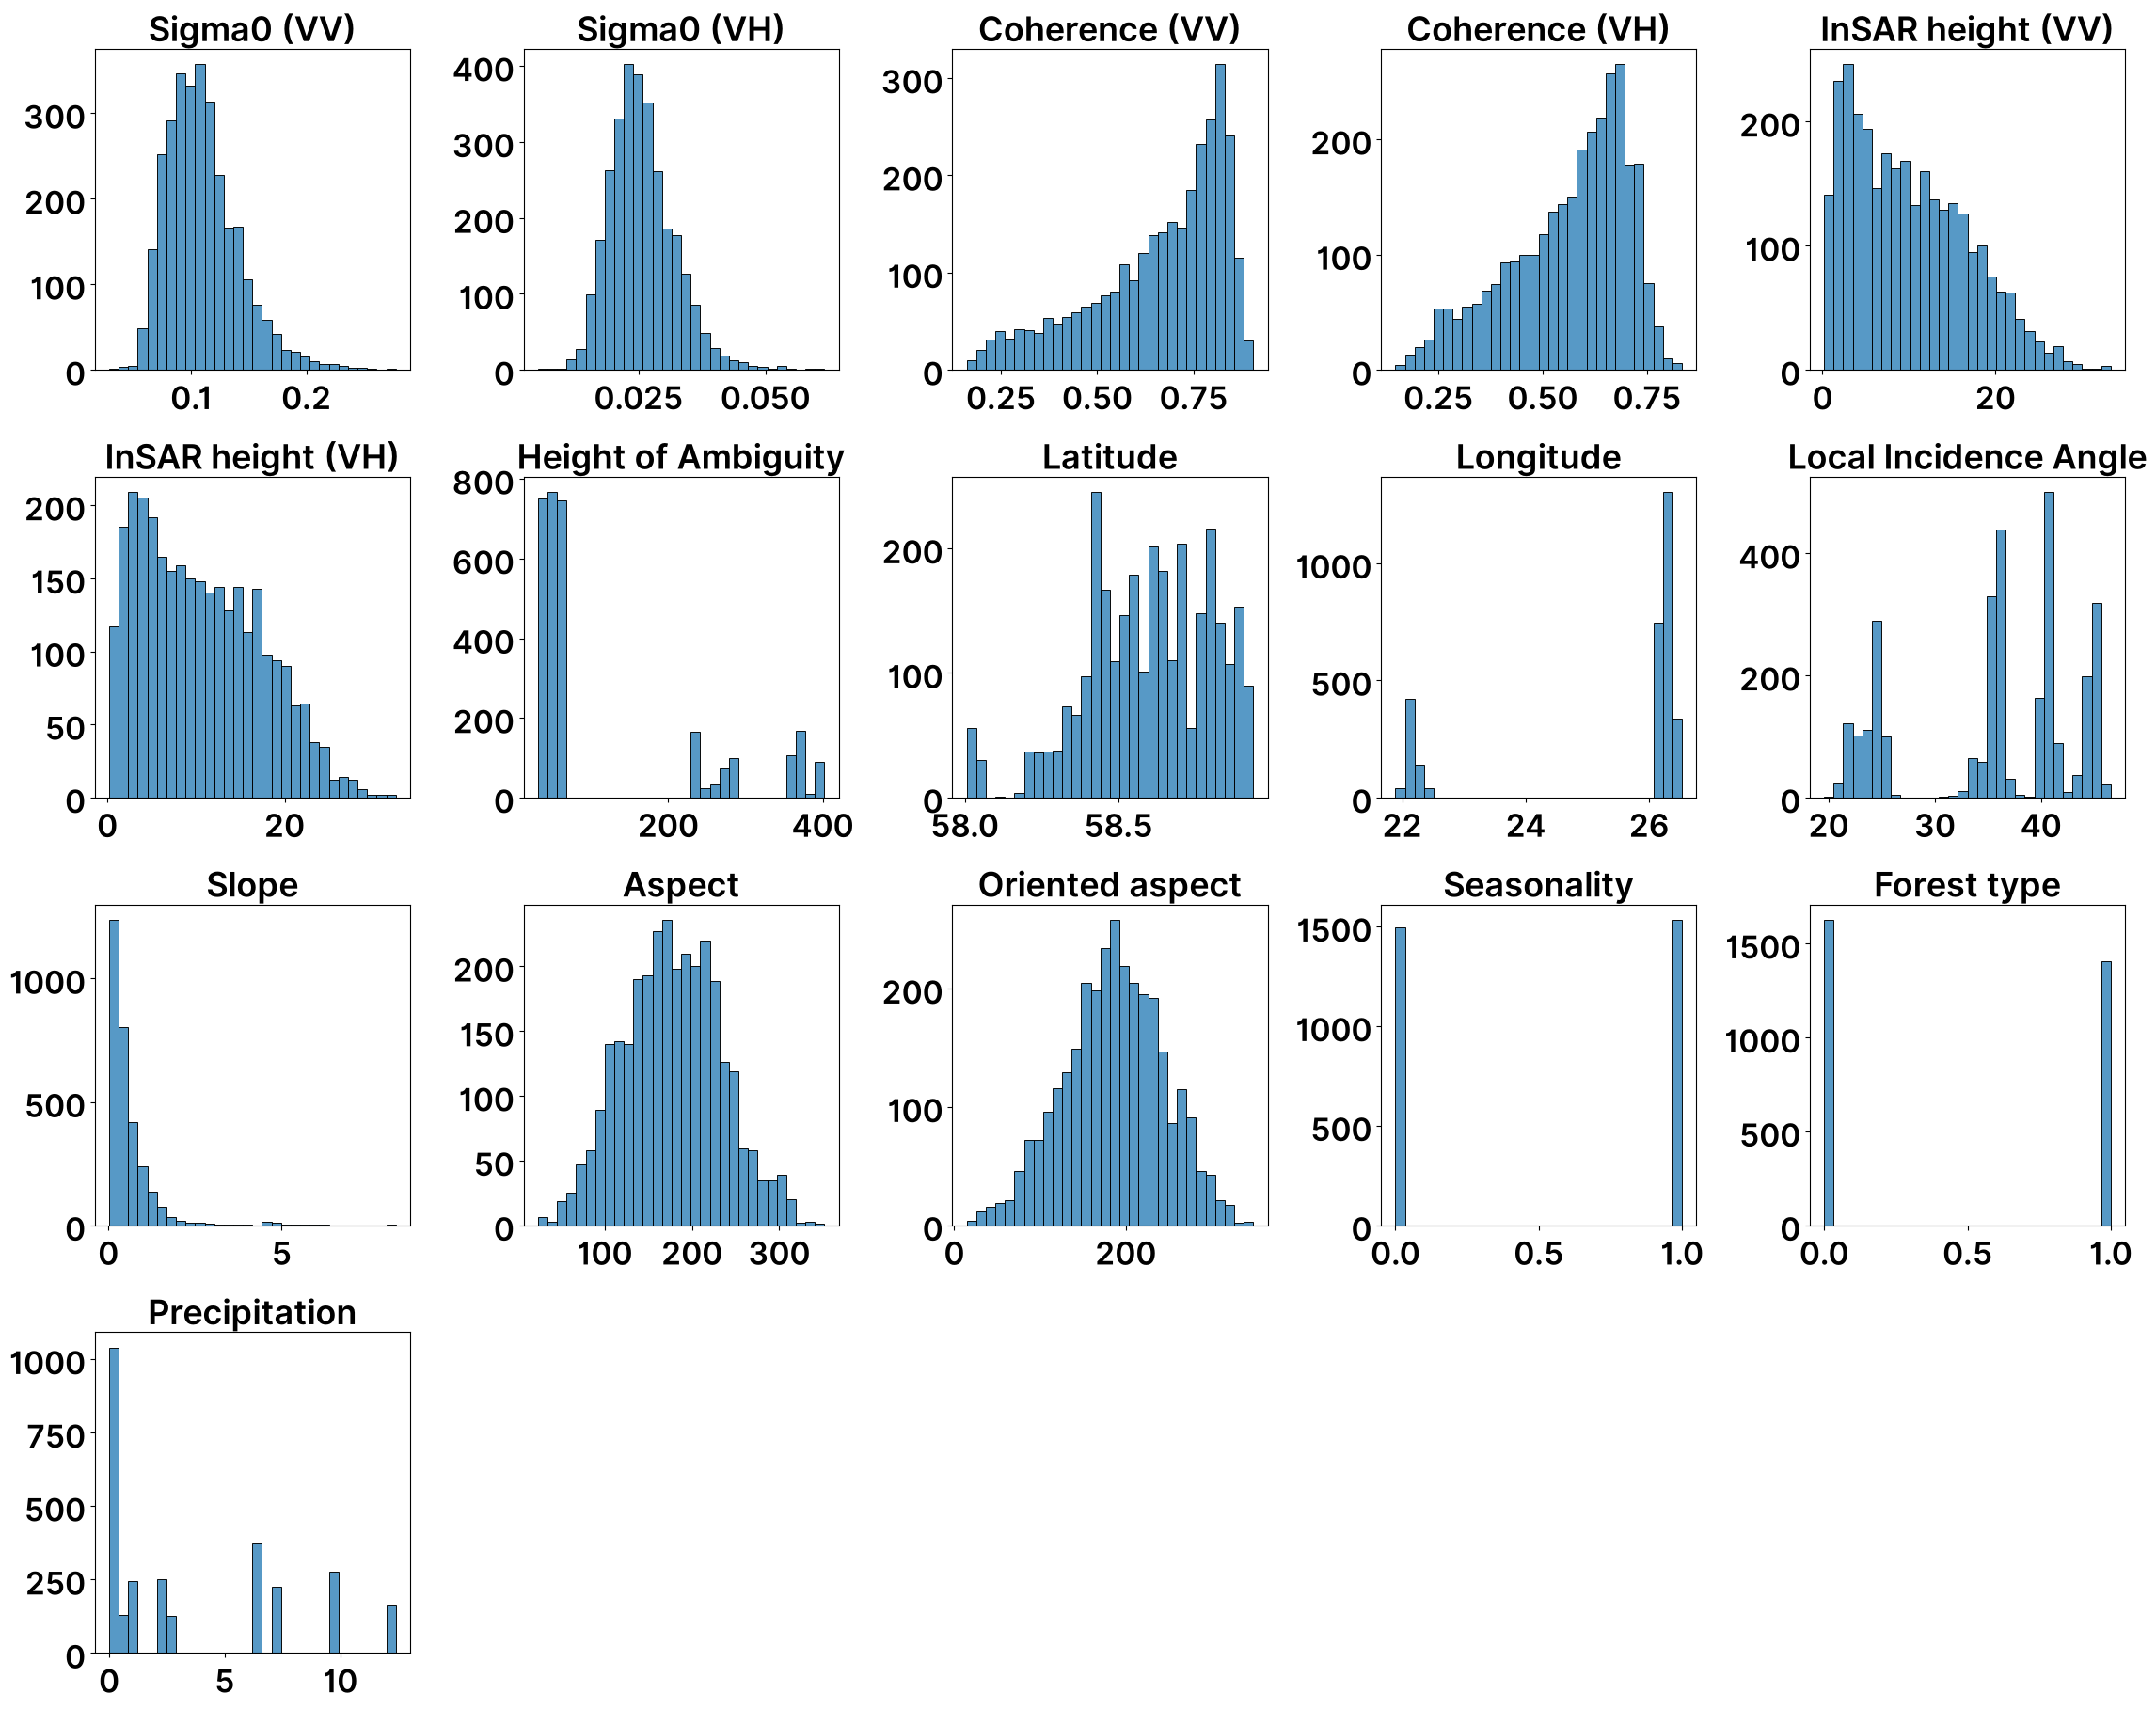

In [ ]:
_exclude = ["elevation_", "eia_"]
histogram_features = [x for x in heatmap_features if not any(e in x for e in _exclude)]
_pretty_names = get_pretty_names(histogram_features)

ncols = 5
nrows = math.ceil(len(histogram_features) / ncols)

if True:
    plt.rcParams.update({
        "font.size": 14,
        "axes.titlesize": 26,
        "axes.labelsize": 24,
        "xtick.labelsize": 24,
        "ytick.labelsize": 24,
    })


fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4.6, nrows * 4.6))
axes = axes.flatten()

for i, col in enumerate(histogram_features):
    sns.histplot(train_df[col], ax=axes[i], bins=30)
    axes[i].set_title(_pretty_names.get(col, col))
    axes[i].set_ylabel("")
    axes[i].set_xlabel("")
    axes[i].set_aspect("auto")

# hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

plt.rcdefaults()

Define training features and prediction target

In [ ]:
top_features = [
    "mst_sigma0_{}_mean",
    "nan_coh_{}_mean",
    "nan_hoa2hc_{}_mean",
    "nan_hoa_00_mean",
    "is_winter",
    "is_coniferous",
]

all_features = [
    "mst_sigma0_{}_mean",
    "nan_coh_{}_mean",
    "nan_hoa2hc_{}_mean",
    "nan_hoa_00_mean",
    "nan_lat_00_mean",
    "nan_lon_00_mean",
    "nan_lia_00_mean",
    "nan_slope_00_mean",
    "nan_aspect_00_mean",
    "nan_orientedaspect_00_mean",
    "is_winter",
    "is_coniferous",
    "prec_mm"
]

prediction_target = "chm_mean"

Random Forest modelling

In [ ]:
def rf(train_df, test_df, training_features, prediction_target, pol):
    print(f"Running for {pol}")

    training_features = [f.format(pol) for f in training_features]
    print("Training features:", training_features)

    # Select features
    X_train, y_train = train_df[training_features], train_df[prediction_target]
    X_test,  y_test  = test_df[training_features], test_df[prediction_target]

    # Hyperparameter search
    param_distributions = {
        "n_estimators": [50, 100, 200, 400],
        "criterion": ["squared_error"],
        "max_depth": [5, 10, 15, 20],
        #"min_samples_split": [2, 5, 8],
        #"min_samples_leaf": [1, 4, 10],
        #"max_features": ["sqrt", "log2", 0.5, 1.0],
        #"bootstrap": [True, False],
    }

    search = RandomizedSearchCV(
        estimator = RandomForestRegressor(
            random_state=get_random_number(),
        ),
        param_distributions=param_distributions,
        n_iter=16,
        cv=5,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1,
        verbose=1,
        random_state=get_random_number()
    )

    search.fit(X_train, y_train)

    best_model = search.best_estimator_
    best_params = search.best_params_

    # Evaluation
    p_test = best_model.predict(X_test)

    r2 = round(r2_score(y_test, p_test), 2)
    mae = round(mean_absolute_error(y_test, p_test), 2)
    rmse = round(root_mean_squared_error(y_test, p_test), 2)

    print(f"R2 {r2}; MAE {mae}; RMSE {rmse}")
    print("Best params:", best_params)

    return {
        "X_test": X_test,
        "p_test": p_test,
        "y_test": y_test,
        "best_model": best_model,
        "best_params": best_params,
        "r2": r2,
        "mae": mae,
        "rmse": rmse,
    }

In [33]:
print("="*10)
rf_all_vv = rf(train_df, test_df, all_features, prediction_target, "vv")
rf_all_vh = rf(train_df, test_df, all_features, prediction_target, "vh")
print("="*10)
rf_top_vv = rf(train_df, test_df, top_features, prediction_target, "vv")
rf_top_vh = rf(train_df, test_df, top_features, prediction_target, "vh")
print("="*10)

Running for vv
Training features: ['mst_sigma0_vv_mean', 'nan_coh_vv_mean', 'nan_hoa2hc_vv_mean', 'nan_hoa_00_mean', 'nan_lat_00_mean', 'nan_lon_00_mean', 'nan_lia_00_mean', 'nan_slope_00_mean', 'nan_aspect_00_mean', 'nan_orientedaspect_00_mean', 'is_winter', 'is_coniferous', 'prec_mm']
Fitting 5 folds for each of 16 candidates, totalling 80 fits


/home/anton/miniconda3/envs/tdx-ts2/lib/python3.12/site-packages/sklearn/model_selection/_search.py:326: UserWarning: The total space of parameters 16 is smaller than n_iter=20. Running 16 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


R2 0.85; MAE 1.61; RMSE 2.15
Best params: {'n_estimators': 400, 'max_depth': 20, 'criterion': 'squared_error'}
Running for vh
Training features: ['mst_sigma0_vh_mean', 'nan_coh_vh_mean', 'nan_hoa2hc_vh_mean', 'nan_hoa_00_mean', 'nan_lat_00_mean', 'nan_lon_00_mean', 'nan_lia_00_mean', 'nan_slope_00_mean', 'nan_aspect_00_mean', 'nan_orientedaspect_00_mean', 'is_winter', 'is_coniferous', 'prec_mm']
Fitting 5 folds for each of 16 candidates, totalling 80 fits


/home/anton/miniconda3/envs/tdx-ts2/lib/python3.12/site-packages/sklearn/model_selection/_search.py:326: UserWarning: The total space of parameters 16 is smaller than n_iter=20. Running 16 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


R2 0.85; MAE 1.58; RMSE 2.15
Best params: {'n_estimators': 400, 'max_depth': 20, 'criterion': 'squared_error'}
Running for vv
Training features: ['mst_sigma0_vv_mean', 'nan_coh_vv_mean', 'nan_hoa2hc_vv_mean', 'nan_hoa_00_mean', 'is_winter', 'is_coniferous']
Fitting 5 folds for each of 16 candidates, totalling 80 fits


/home/anton/miniconda3/envs/tdx-ts2/lib/python3.12/site-packages/sklearn/model_selection/_search.py:326: UserWarning: The total space of parameters 16 is smaller than n_iter=20. Running 16 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


R2 0.85; MAE 1.65; RMSE 2.17
Best params: {'n_estimators': 400, 'max_depth': 20, 'criterion': 'squared_error'}
Running for vh
Training features: ['mst_sigma0_vh_mean', 'nan_coh_vh_mean', 'nan_hoa2hc_vh_mean', 'nan_hoa_00_mean', 'is_winter', 'is_coniferous']
Fitting 5 folds for each of 16 candidates, totalling 80 fits


/home/anton/miniconda3/envs/tdx-ts2/lib/python3.12/site-packages/sklearn/model_selection/_search.py:326: UserWarning: The total space of parameters 16 is smaller than n_iter=20. Running 16 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


R2 0.83; MAE 1.68; RMSE 2.27
Best params: {'n_estimators': 400, 'max_depth': 10, 'criterion': 'squared_error'}


SHAP Explanation

In [34]:
explainer_all_vv = shap.TreeExplainer(rf_all_vv["best_model"])
explanation_all_vv = explainer_all_vv(rf_all_vv["X_test"])

_pretty_names = get_pretty_names(explanation_all_vv.feature_names)

explanation_all_vv.feature_names = [
    _pretty_names.get(f, f) for f in explanation_all_vv.feature_names
]

In [35]:
explainer_all_vh = shap.TreeExplainer(rf_all_vh["best_model"])
explanation_all_vh = explainer_all_vh(rf_all_vh["X_test"])

_pretty_names = get_pretty_names(explanation_all_vh.feature_names)

explanation_all_vh.feature_names = [
    _pretty_names.get(f, f) for f in explanation_all_vh.feature_names
]

In [36]:
explainer_top_vv = shap.TreeExplainer(rf_top_vv["best_model"])
explanation_top_vv = explainer_top_vv(rf_top_vv["X_test"])

_pretty_names = get_pretty_names(explanation_top_vv.feature_names)

explanation_top_vv.feature_names = [
    _pretty_names.get(f, f) for f in explanation_top_vv.feature_names
]

In [37]:
explainer_top_vh = shap.TreeExplainer(rf_top_vh["best_model"])
explanation_top_vh = explainer_top_vh(rf_top_vh["X_test"])

_pretty_names = get_pretty_names(explanation_top_vh.feature_names)

explanation_top_vh.feature_names = [
    _pretty_names.get(f, f) for f in explanation_top_vh.feature_names
]

General plots

In [ ]:
def plot_graphs(shap_exp, y_test, p_test):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi=400)

    # SHAP Beeswarm
    plt.sca(axes[0])
    shap.plots.beeswarm(
        shap_exp,
        max_display=20,
        plot_size=None,
        show=False,
    )
    axes[0].set_xscale("symlog")
    axes[0].set_title("SHAP Feature Importance")
    axes[0].set_xlabel("SHAP value\n(impact on model output)")

    axes[0].tick_params(axis="y", colors="black")
    axes[0].tick_params(axis="x", colors="black")

    # Scatter plot of predicted vs. true
    axes[1].scatter(y_test, p_test, alpha=0.5)
    axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)  # Just diagonal line
    axes[1].set_xlabel("True Values")
    axes[1].set_ylabel("Predicted Values")
    axes[1].set_title("Predicted vs True")
    
    # Histogram of predicted vs. true
    combined_min = min(y_test.min(), p_test.min())
    combined_max = max(y_test.max(), p_test.max())
    
    sns.histplot(y_test, ax=axes[2], label="True", alpha=0.5, shrink=0.8, binrange=(combined_min, combined_max), bins=30)
    sns.histplot(p_test, ax=axes[2], label="Predicted", alpha=0.5, shrink=0.8, binrange=(combined_min, combined_max), bins=30)
    axes[2].set_xlabel("Value")
    axes[2].set_ylabel("Count")
    axes[2].set_title("Distribution: Predicted vs True")
    axes[2].legend()

    plt.tight_layout()
    plt.show()

findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.


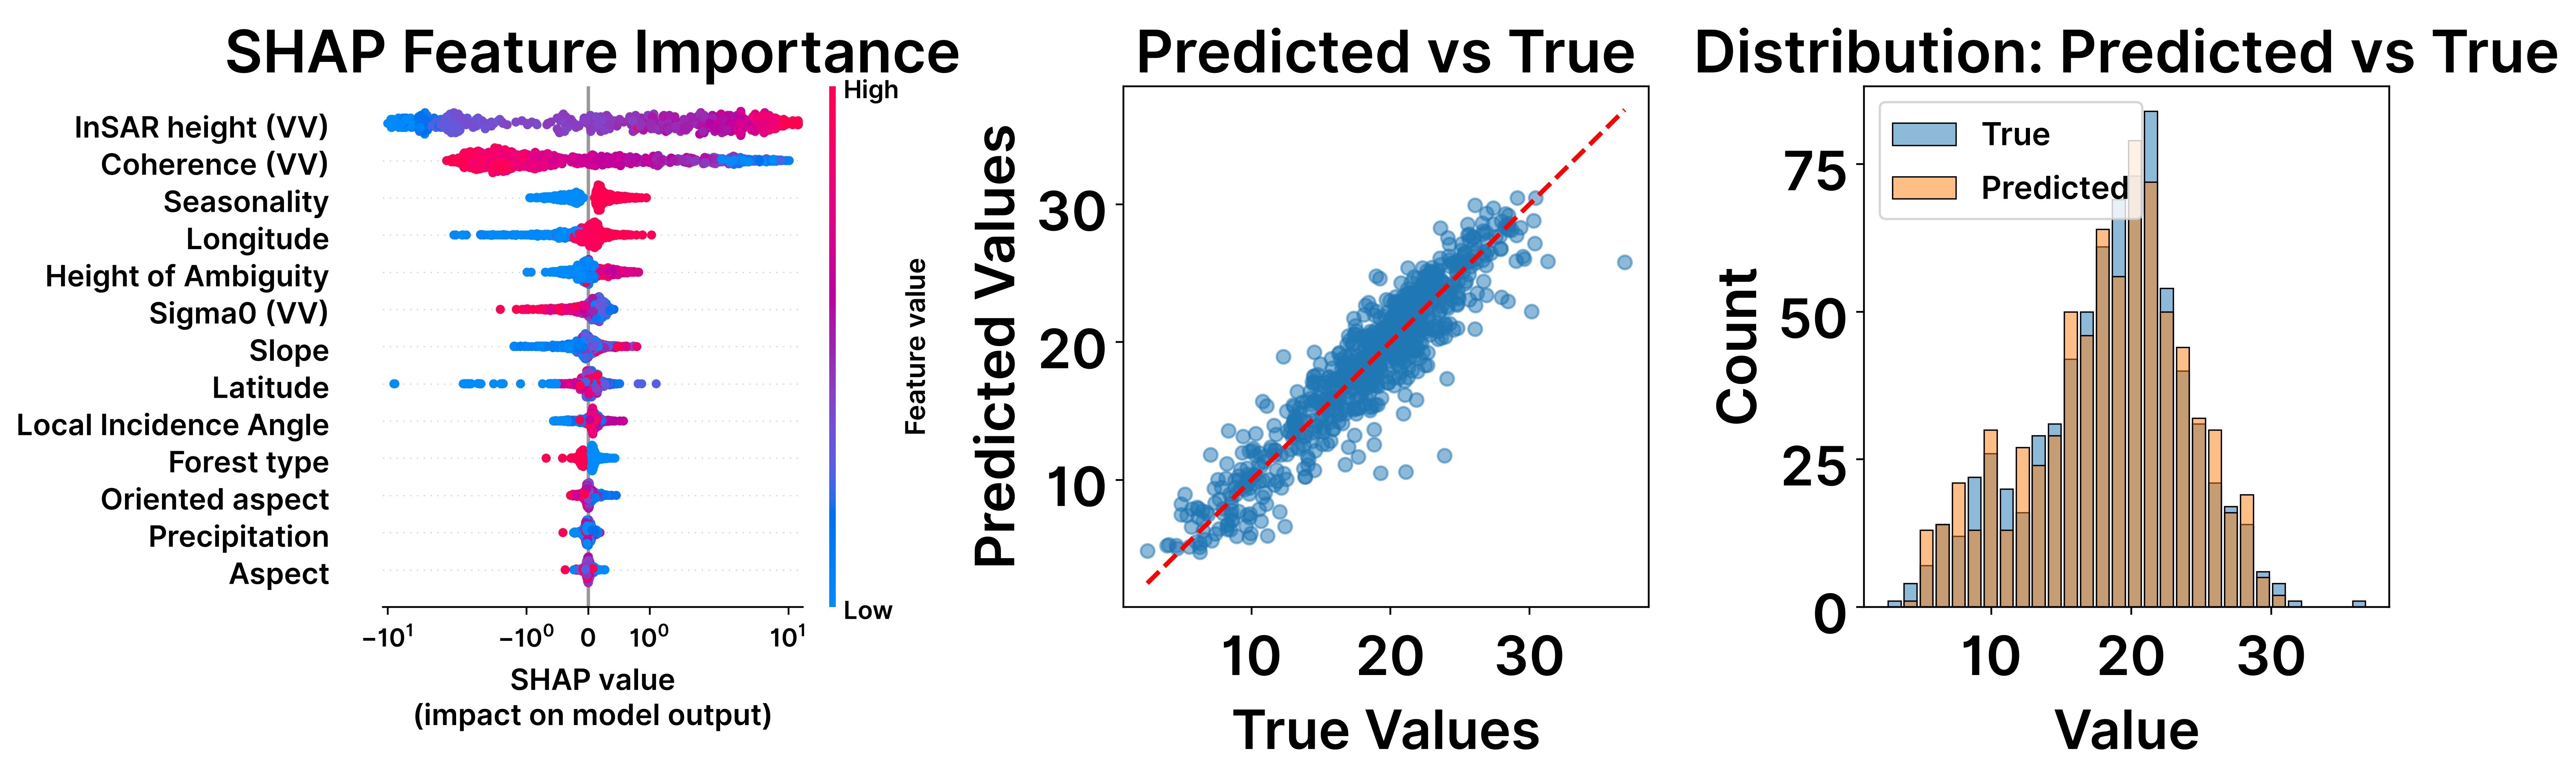

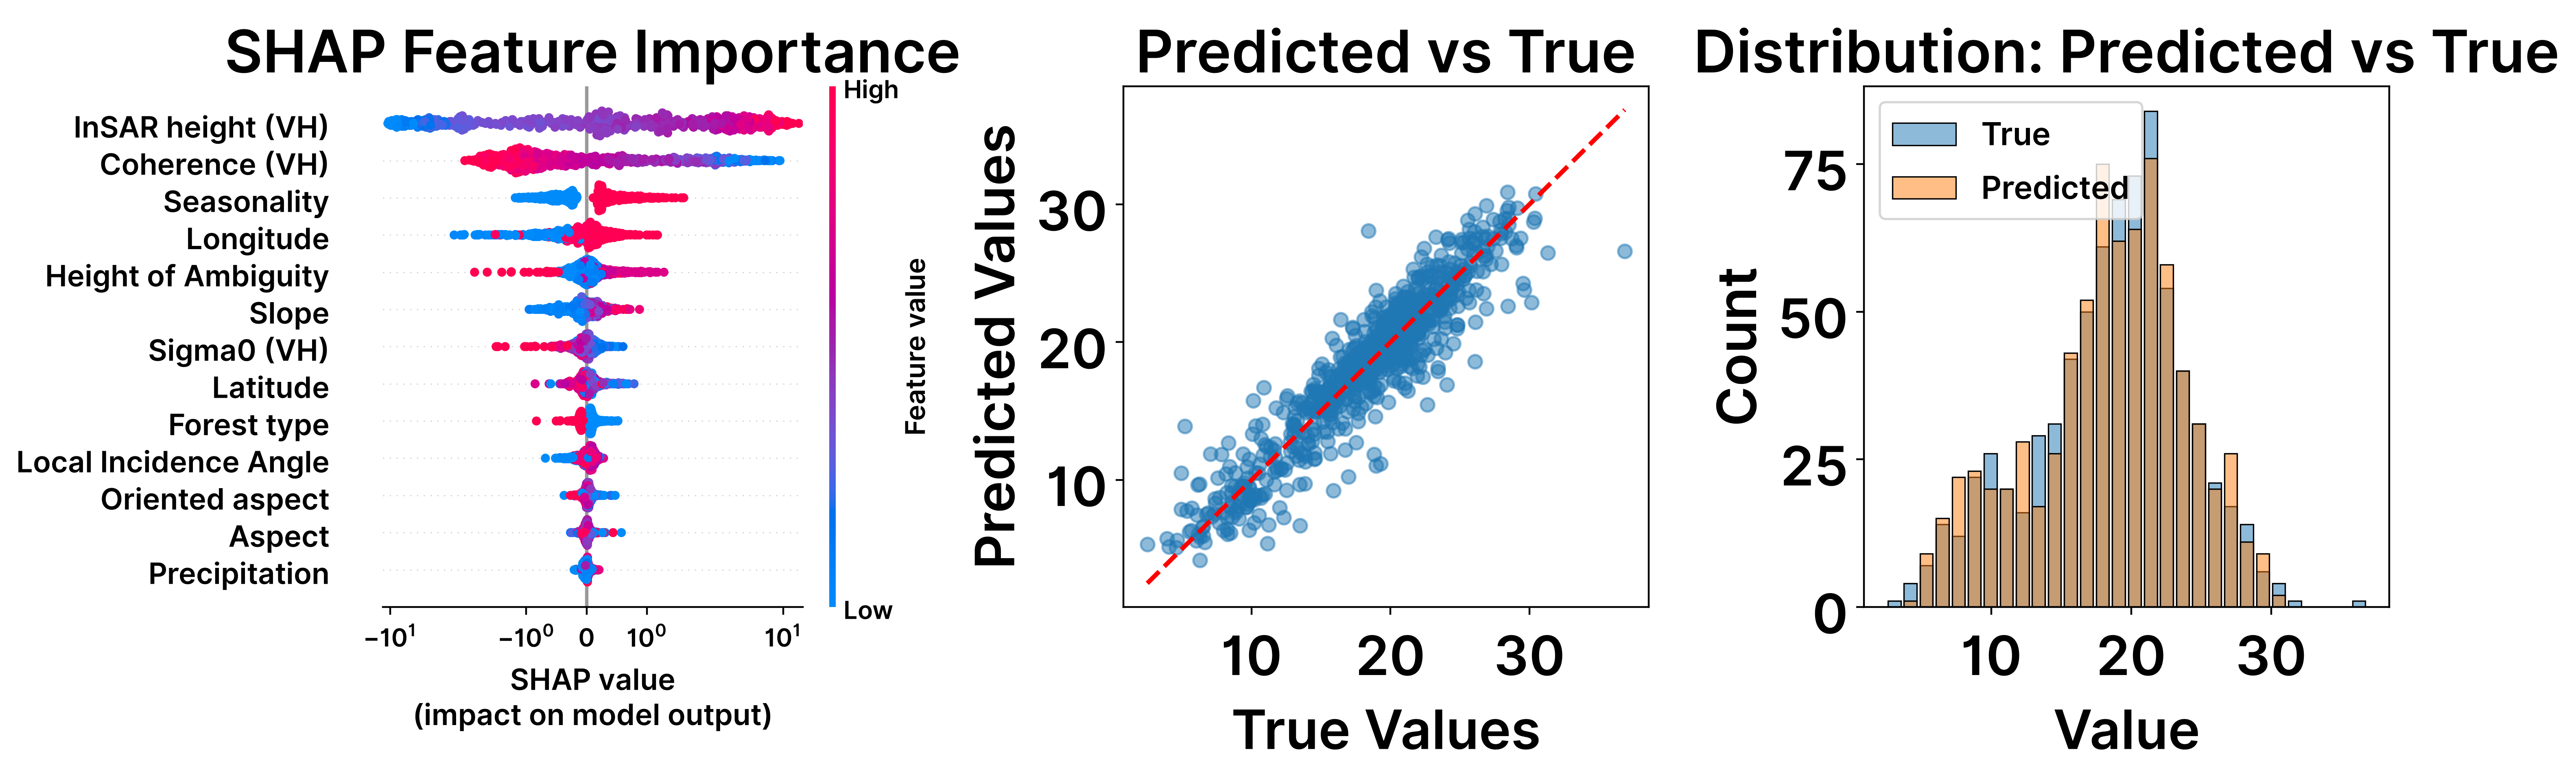

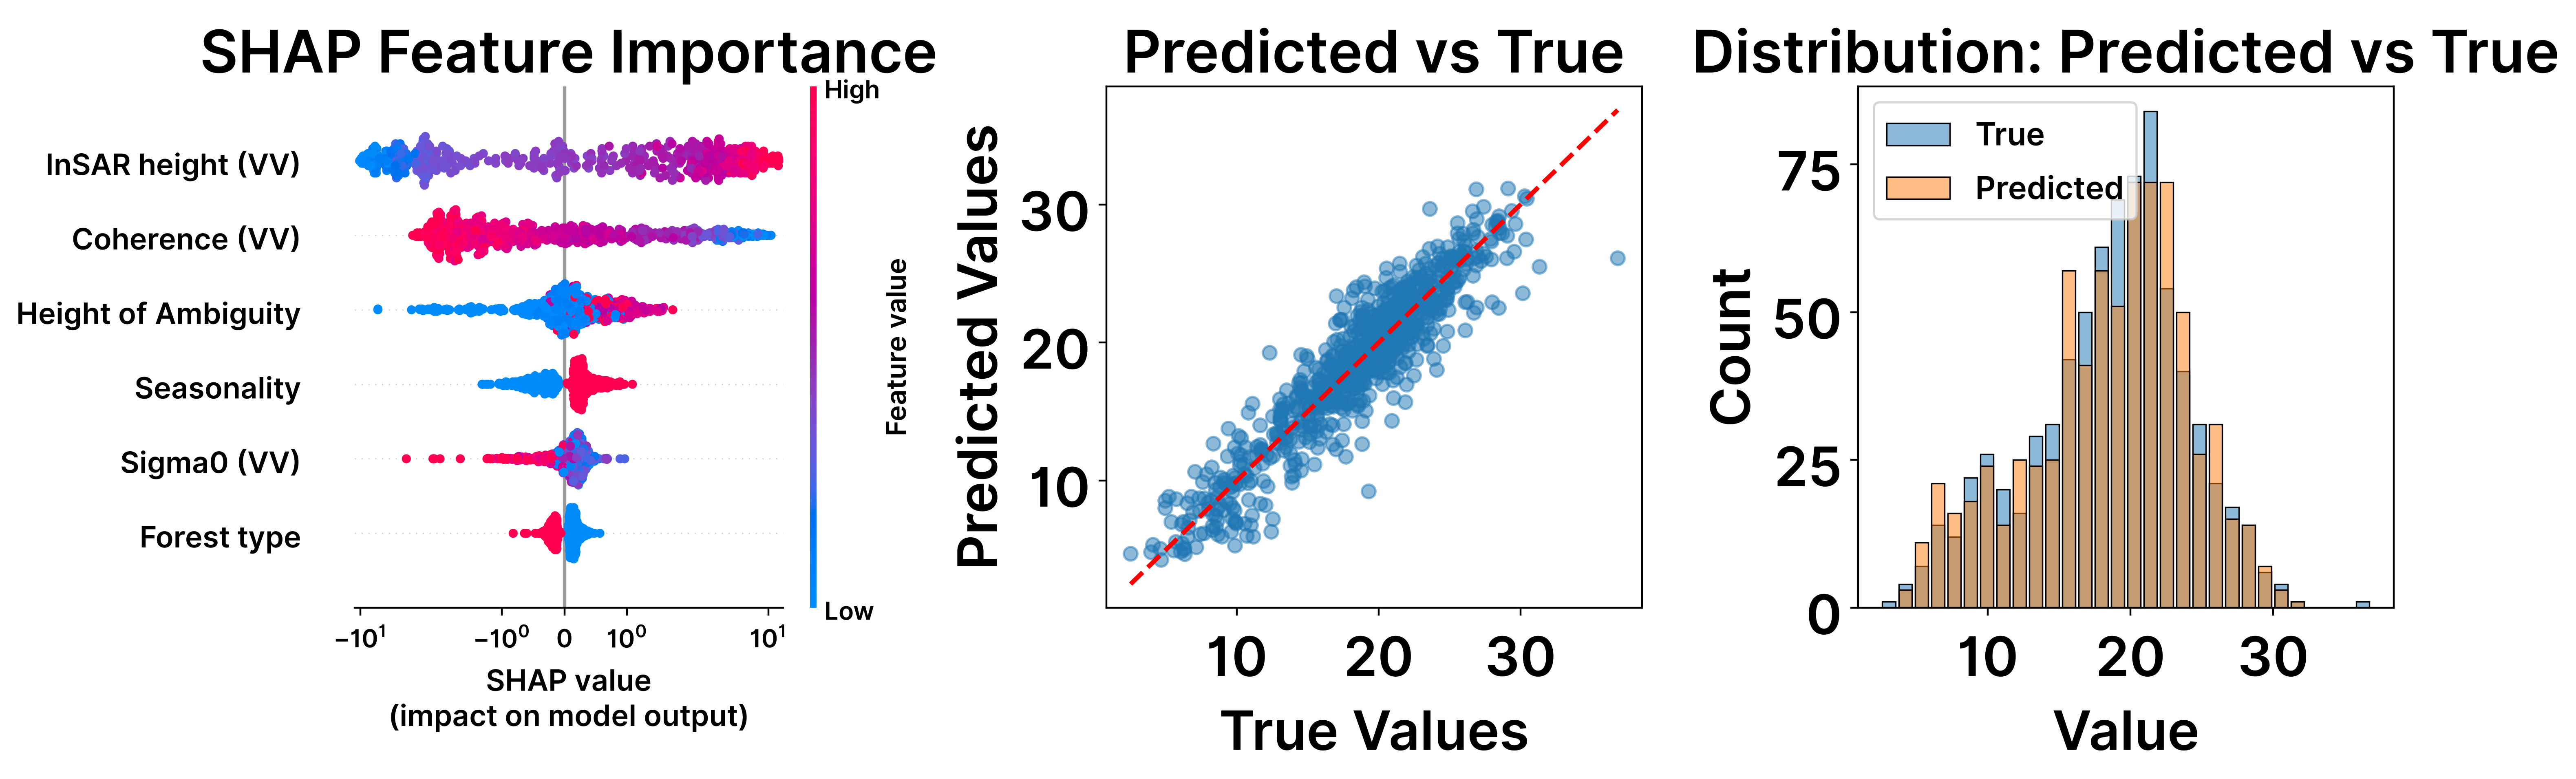

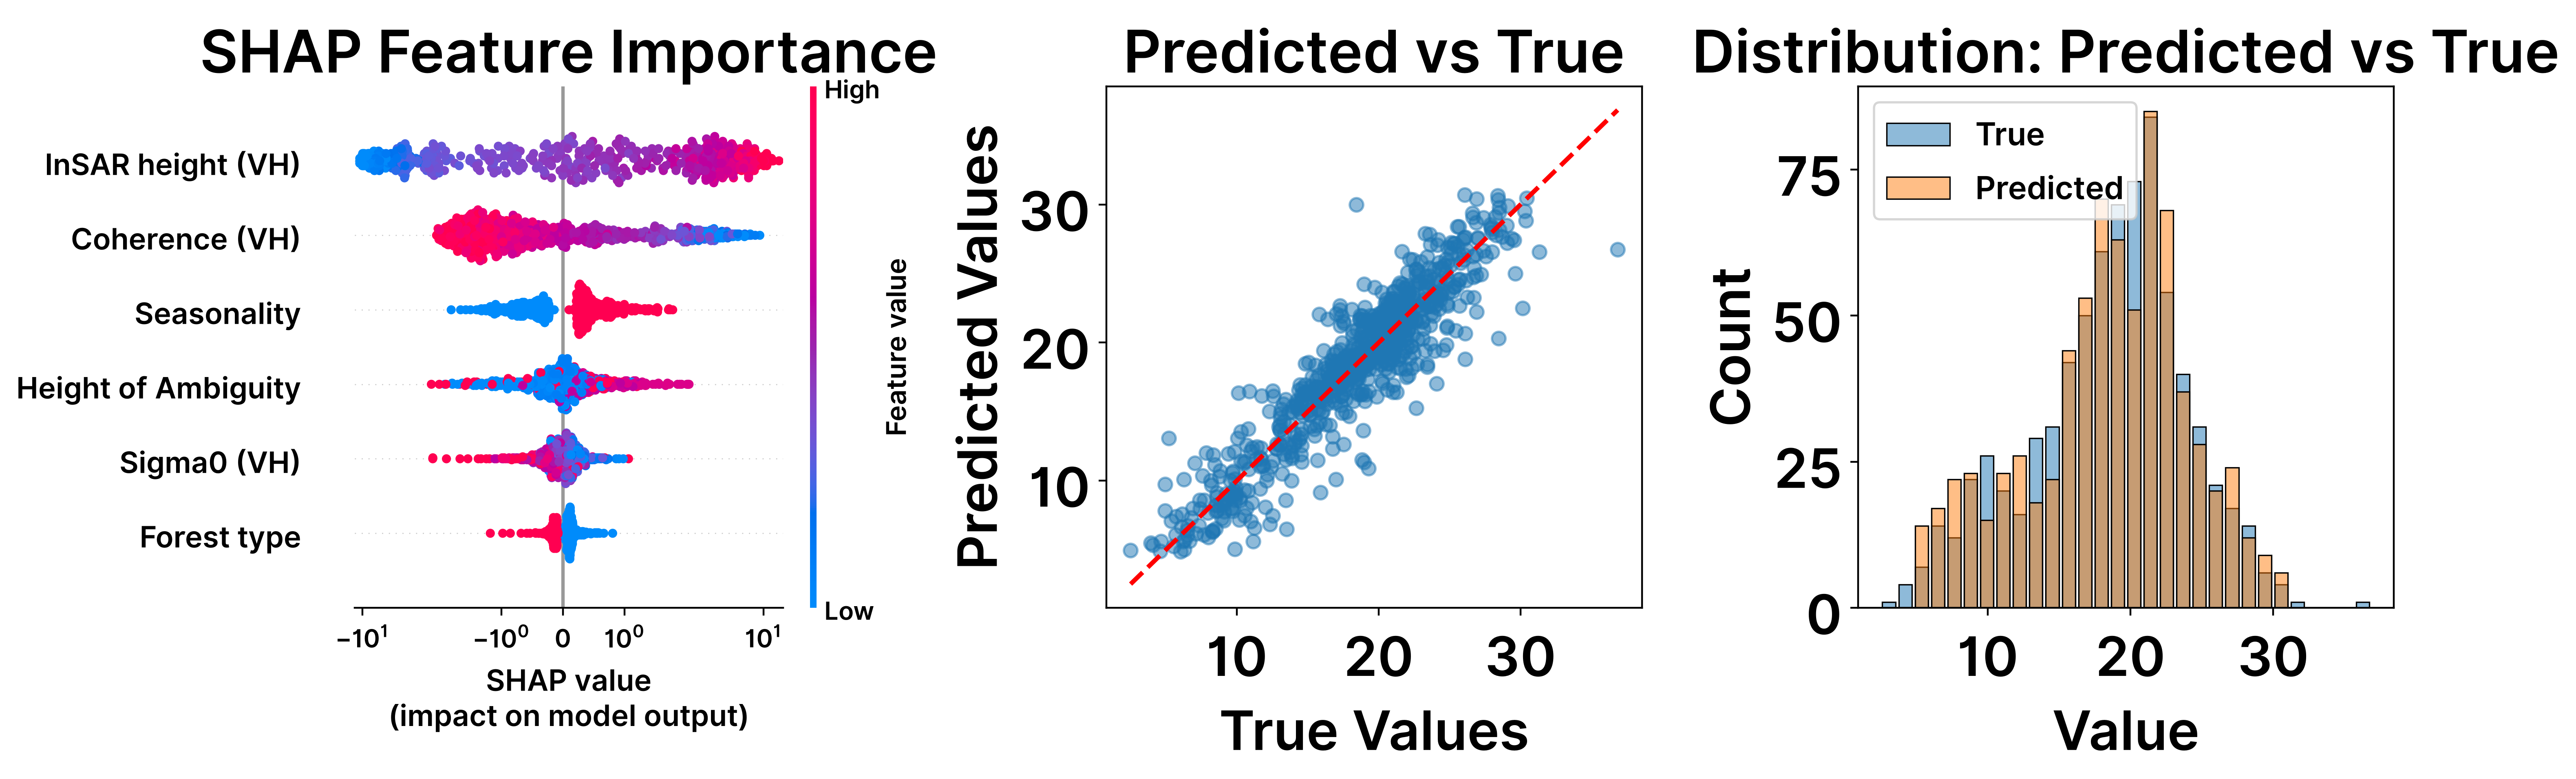

In [39]:
plot_graphs(explanation_all_vv, rf_all_vv["y_test"], rf_all_vv["p_test"])
plot_graphs(explanation_all_vh, rf_all_vh["y_test"], rf_all_vh["p_test"])

plot_graphs(explanation_top_vv, rf_top_vv["y_test"], rf_top_vv["p_test"])
plot_graphs(explanation_top_vh, rf_top_vh["y_test"], rf_top_vh["p_test"])

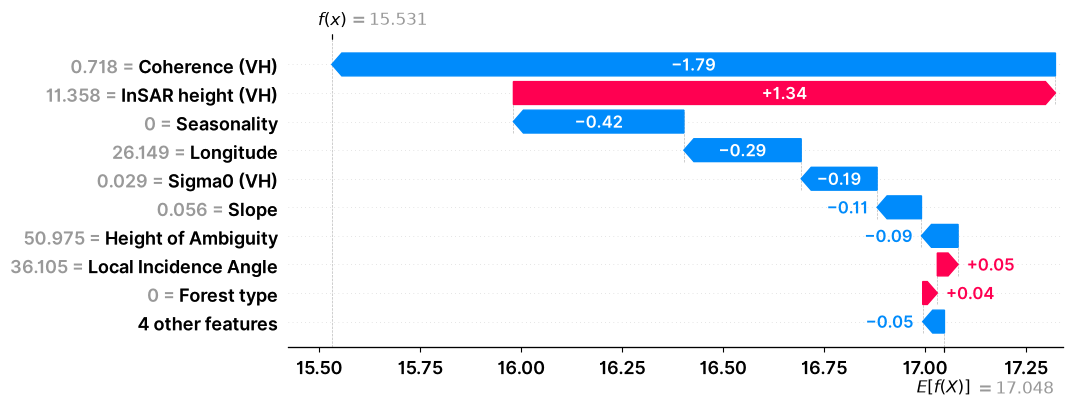

In [ ]:
idx = 242

shap.plots.waterfall(explanation_all_vh[idx], max_display=10, show=False)

fig = plt.gcf()
fig.set_size_inches(10, 4, forward=True)

plt.show()

SHAP Interactions

In [45]:
interaction_top_vv = explainer_top_vv.shap_interaction_values(rf_top_vv["X_test"])

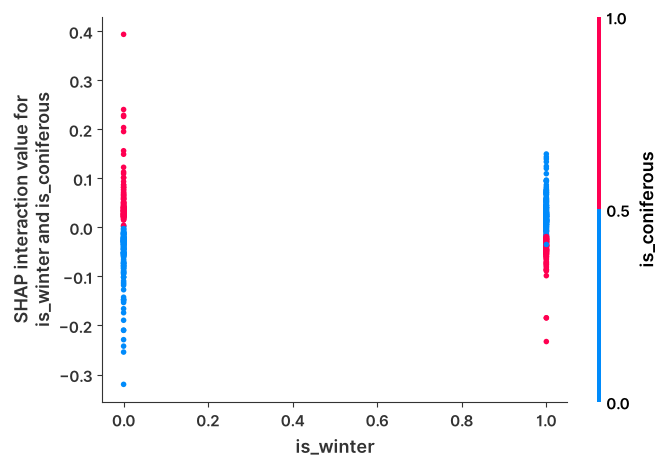

In [46]:
shap.dependence_plot(
    (
        "is_winter",
        "is_coniferous",
    ),
    interaction_top_vv, rf_top_vv["X_test"],
    display_features=rf_top_vv["X_test"]
)

In [ ]:
interaction_top_vh = explainer_top_vh.shap_interaction_values(rf_top_vh["X_test"])

In [ ]:
fig, ax = plt.subplots(figsize=(2, 4), dpi=300)

shap.dependence_plot(
    ("is_winter", "is_coniferous"),
    interaction_top_vh,
    rf_top_vh["X_test"],
    display_features=rf_top_vh["X_test"],
    ax=ax,
    show=False
)

ax.tick_params(axis='y', colors='black')
ax.tick_params(axis='x', colors='black')

ax.set_xticks([0, 1])
ax.set_xlim(-0.15, 1.15)  # tighten whitespace around the two categories

plt.savefig("dependence_plot.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
#import numpy as np
#import pandas as pd
#import seaborn as sns
#import matplotlib.pyplot as plt

X_test = rf_top_vh["X_test"]
feature_names = list(X_test.columns)

idx_winter = feature_names.index("is_winter")
idx_conif = feature_names.index("is_coniferous")

# off-diagonal SHAP interaction values are split between [i,j] and [j,i],
# so multiply by 2 to get the full interaction effect (matches shap's own dependence_plot)
interaction_values = interaction_top_vh[:, idx_winter, idx_conif] * 2

df_plot = pd.DataFrame({
    "is_winter": X_test["is_winter"].values,
    "is_coniferous": X_test["is_coniferous"].values,
    "interaction_value": interaction_values,
})

In [ ]:
# --- Human-readable labels ---
season_map = {0: "Leaf-on", 1: "Leaf-off"}
forest_map = {0: "Deciduous", 1: "Coniferous"}
colors = {0: "#008BFB", 1: "#FF0052"}  # keyed by is_coniferous

fig, axes = plt.subplots(2, 1, figsize=(3.5, 4.5), dpi=300, sharex=True, sharey=True)

# shared bins across both panels so histograms are comparable
bins = np.linspace(df_plot["interaction_value"].min(), df_plot["interaction_value"].max(), 31)

for ax, winter_val in zip(axes, [0, 1]):
    subset = df_plot[df_plot["is_winter"] == winter_val]

    for conif_val in [0, 1]:
        vals = subset.loc[subset["is_coniferous"] == conif_val, "interaction_value"]
        ax.hist(
            vals,
            bins=bins,
            orientation="horizontal",
            color=colors[conif_val],
            alpha=0.6,
            label=forest_map[conif_val],
        )

    ax.set_title(season_map[winter_val], fontsize=12)
    ax.tick_params(labelsize=11)
    ax.set_ylim(-0.75, 0.75)
    ax.set_ylabel("SHAP \n Interaction value", fontsize=12)

axes[1].set_xlabel("Count", fontsize=12)
axes[0].legend(fontsize=8, title_fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Set DPI globally before plotting ---
plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.dpi"] = 300

# --- Make a human-readable copy of the winter column for faceting ---
df_plot["Season"] = df_plot["is_winter"].map({0: "Non-winter", 1: "Winter"})
df_plot["Forest type"] = df_plot["is_coniferous"].map({0: "Non-coniferous", 1: "Coniferous"})

g = sns.displot(
    data=df_plot,
    y="interaction_value",
    hue="Forest type",
    col="Season",
    kind="hist",
    palette={"Non-coniferous": "tab:blue", "Coniferous": "crimson"},
    bins=30,
    height=5,
    aspect=0.6,
)

# --- Axis labels with custom font size ---
g.set_axis_labels(
    "Count",
    "SHAP interaction value for\nSeasonality and Forest type",
    fontsize=13,
)

# --- Facet titles (currently "Season = Winter" etc.) made cleaner ---
g.set_titles("{col_name}", size=13)

# --- Tick label font size ---
for ax in g.axes.flat:
    ax.tick_params(labelsize=11)

plt.tight_layout()
plt.show()

In [ ]:
#shap_interaction = explainer.shap_interaction_values(X_test)

In [ ]:
shap_explanation = prettify_shap_names(shap_explanation)

In [ ]:
def plot_graphs(r2, mae, rmse, shap_test, y_test, p_test, best_params, fig_file):
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # --- 1. SHAP Beeswarm ---
    plt.sca(axes[0])
    shap.plots.beeswarm(
        shap_test,
        max_display=20,
        plot_size=None,
        show=False,
    )
    axes[0].set_xscale("symlog")
    axes[0].set_title("SHAP Feature Importance")

    # --- 2. Scatter: Predicted vs True ---
    #print("predict")
    #y_pred = rf.predict(X_test)

    axes[1].scatter(y_test, p_test, alpha=0.5)
    axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)  # Just diagonal line
    axes[1].set_xlabel("True Values")
    axes[1].set_ylabel("Predicted Values")
    axes[1].set_title("Predicted vs True")
    
    # --- 3. Histogram: Predicted vs True ---
    #combined_min = min(y_test.min(), p_test.min())
    #combined_max = max(y_test.max(), p_test.max())
    #
    #sns.histplot(y_test, ax=axes[2], label='True', alpha=0.5, shrink=0.8,
    #             binrange=(combined_min, combined_max), bins=30)
    #sns.histplot(p_test, ax=axes[2], label='Predicted', alpha=0.5, shrink=0.8,
    #             binrange=(combined_min, combined_max), bins=30)
    #axes[2].set_xlabel("Value")
    #axes[2].set_ylabel("Count")
    #axes[2].set_title("Distribution: Predicted vs True")
    #axes[2].legend()
#
    #_text = ["Metrics test:", f"R2: {r2}", f"MAE: {mae}", f"RMSE: {rmse}", f"Datasets size:{len(X_train)} / {len(X_test)}"]
    #plt.figtext(0.0, 0.0, "\n".join(_text), ha='left', va='top')
#
    #_text = [f'{k}={v}' for k, v in best_params.items()]
    #plt.figtext(0.2, 0.0, "\n".join(_text), ha='left', va='top')

    plt.tight_layout()
    #os.makedirs(os.path.dirname(fig_file), exist_ok=True)
    #plt.savefig(fig_file, bbox_inches="tight", dpi=150)
    plt.close()


fig_file = os.path.join(os.getcwd(), "rf_all_modelling", f"S1_VV_LOG_DB.png")
plot_graphs(
    r2,
    mae,
    rmse, 
    shap_explanation, 
    y_test, 
    p_test, 
    best_params, 
    fig_file
)

Interactions

In [ ]:
shap.summary_plot(shap_interaction, X_test, show=False)


plt.show()


In [ ]:
X_test.columns

In [ ]:
shap.dependence_plot(
    (
        #"nan_hoa2hc_vv_median",
        "nan_hoa_00_mean",
        "nan_coh_vh_mean",
        #"is_large_hoa",
        #"md_group",
        #"mst_sigma0_vv_median",
        #"is_winter",
        #"md_master_satellite",
        #"is_coniferous",
    ),
    shap_interaction, X_test,
    display_features=X_test
)

In [ ]:
from sklearn.inspection import PartialDependenceDisplay

fig, ax = plt.subplots(figsize=(20, 30))  # adjust to your needs

PartialDependenceDisplay.from_estimator(
    best_model, X_train, X_train.columns,
    ax=ax
)

In [ ]:
X_train[X_train.isna().any(axis=1)]

Scatter plots

In [ ]:
shap.plots.scatter(
    shap_explanation[:, "mst_sigma0_vv_median"],
    #color=shap_explanation[:, "is_large_hoa"]
)